<a href="https://colab.research.google.com/github/anfalear/proyectos/blob/main/Mision2_ProcessMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Misión 2 - Process Mining**

Análisis de datos Intermedio
Talento Tech Bucaramanga

Integrantes:



Andrés Fabián Leal Archila





# **Ejercicio 1: Caso HELP DESK simulado**

Introducción: Análisis de Procesos con PM4Py - Caso Help Desk

Objetivo del taller: Este taller tiene como propósito simular un proceso realista, que se analiza usando técnicas de minería de procesos identificando patrones, anomalías, cuellos de botella y la generación propuestas de mejora con base en datos.
Contexto del caso: Una empresa tiene un sistema de mesa de ayuda que recibe tickets de soporte técnico. Estos tickets atraviesan distintas etapas: recepción, diagnóstico, resolución, o en algunos casos, escalamiento o cancelación. Se trabajará con un registro simulado de 1000 casos (trazas), y deberá analizarlo con PM4Py en Python.

Metodología:

Preparación del entorno: Para la preparación del entorno se seguirán las siguientes instrucciones:
Instalar PM4Py y bibliotecas necesarias.
Ejecutar el código de simulación, lo cual se realiza en la siguiente celda donde se obtienen las simulaciones y las gráficas solicitadas.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cudf/pandas/__init__.py:51: UserWarning: Failed to check cudaDevAttrConcurrentManagedAccess with error 35
  warnings.warn(str(e))


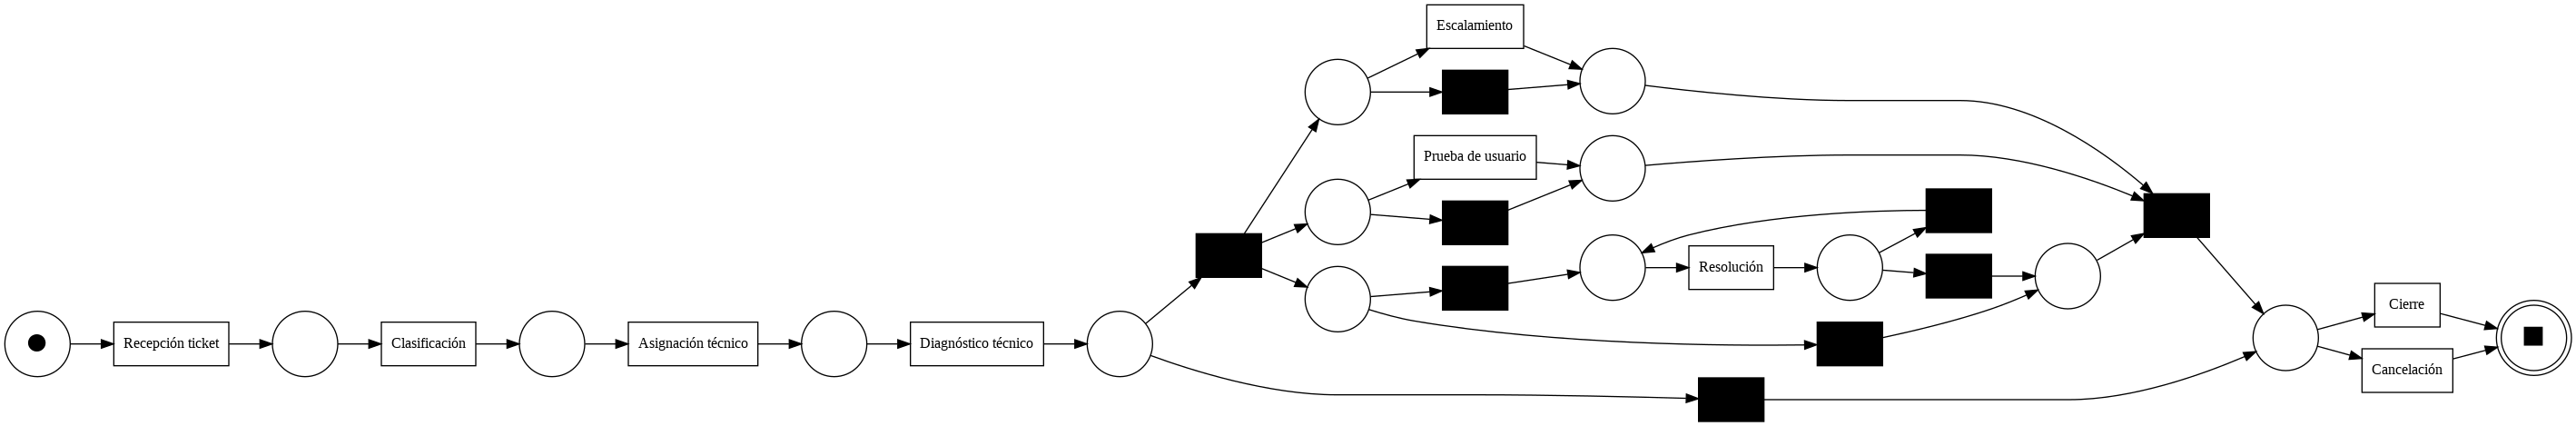

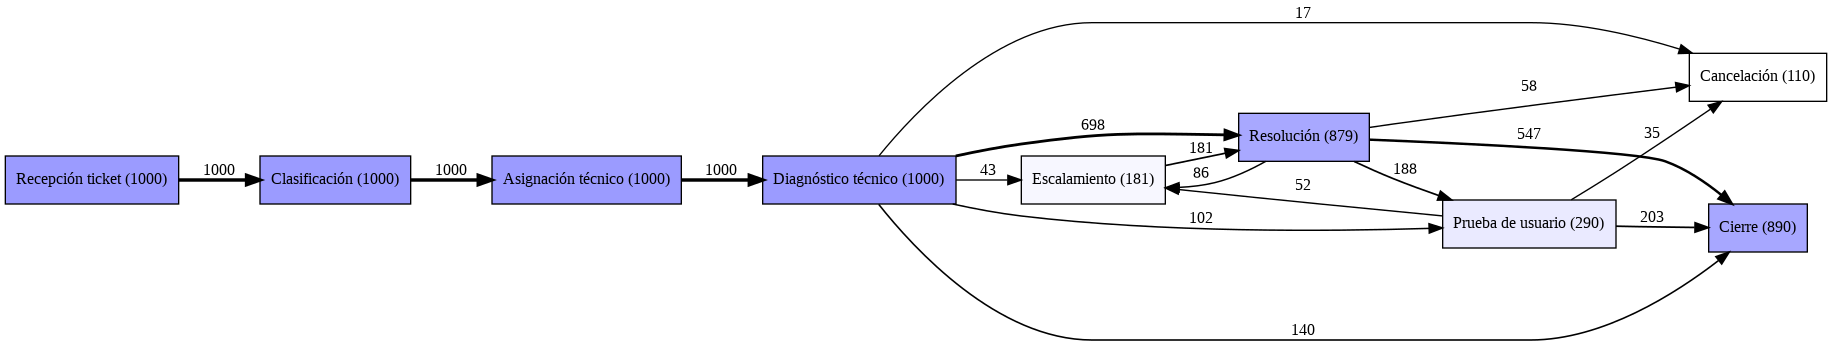


📊 Estadísticas del proceso Help Desk:

1. Actividades de inicio: {'Recepción ticket': 1000}
2. Actividades de fin: {'Cierre': 890, 'Cancelación': 110}
3. Total de tickets: 1000
4. Frecuencia de actividades:
   - Recepción ticket: 1000
   - Clasificación: 1000
   - Asignación técnico: 1000
   - Diagnóstico técnico: 1000
   - Cierre: 890
   - Resolución: 879
   - Prueba de usuario: 290
   - Escalamiento: 181
   - Cancelación: 110

5. Principales variantes:
   - ('Recepción ticket', 'Clasificación', 'Asignación técnico', 'Diagnóstico técnico', 'Resolución', 'Cierre'): 366 tickets
   - ('Recepción ticket', 'Clasificación', 'Asignación técnico', 'Diagnóstico técnico', 'Cierre'): 140 tickets
   - ('Recepción ticket', 'Clasificación', 'Asignación técnico', 'Diagnóstico técnico', 'Resolución', 'Prueba de usuario', 'Cierre'): 139 tickets
   - ('Recepción ticket', 'Clasificación', 'Asignación técnico', 'Diagnóstico técnico', 'Resolución', 'Escalamiento', 'Resolución', 'Cierre'): 86 tickets
   -

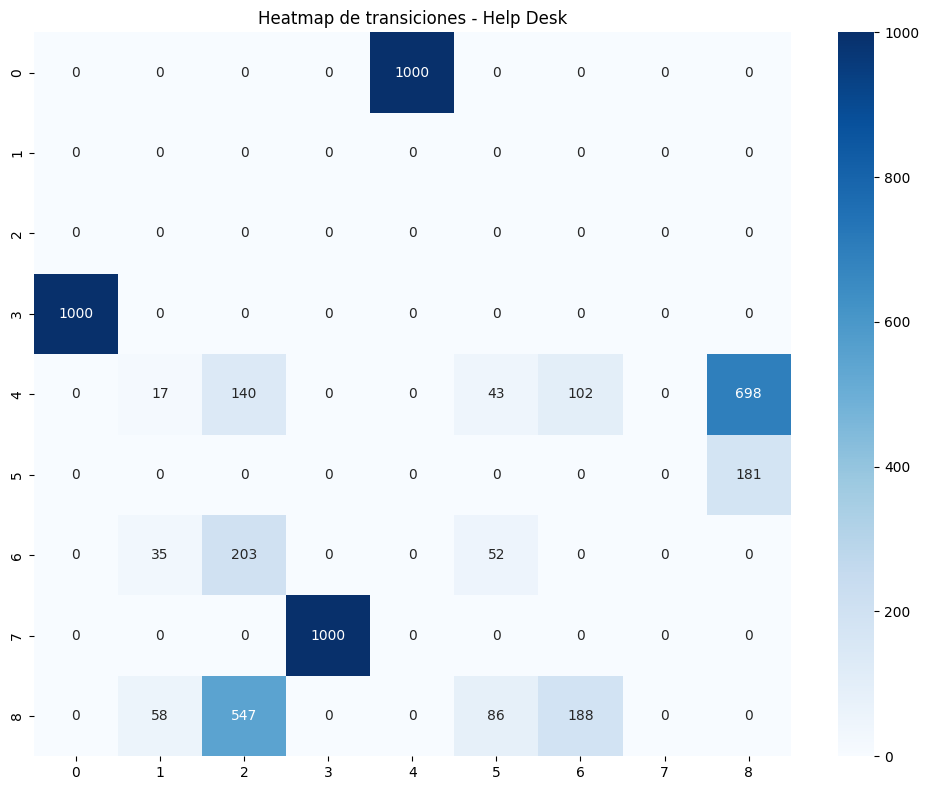

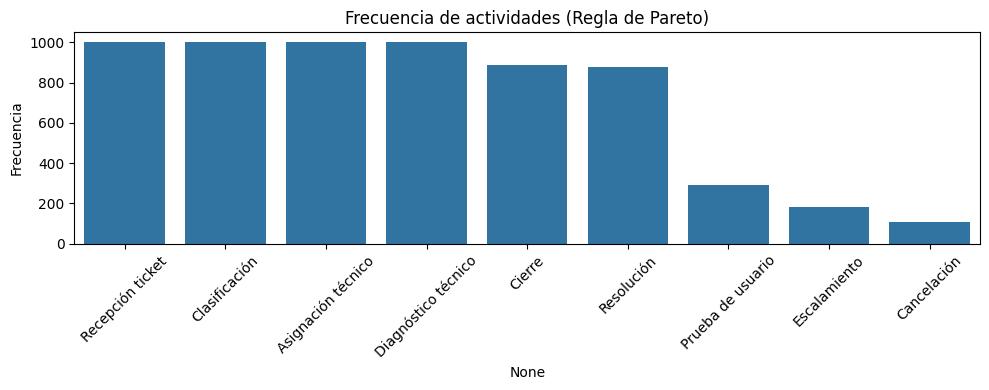

In [1]:
!pip install pm4py

import pandas as pd
import random
from datetime import datetime, timedelta
from pm4py.convert import convert_to_event_log
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petri_net import visualizer as pn_vis
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.statistics.start_activities.log.get import get_start_activities
from pm4py.statistics.end_activities.log.get import get_end_activities
from pm4py.statistics.traces.generic.log import case_statistics
from pm4py.statistics.attributes.log import get as attr_stats
from pm4py.algo.discovery.dfg import algorithm as dfg
from pm4py.visualization.dfg import visualizer as dfg_vis

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter

# ---------------------------
# PARTE 1: Simulación del proceso
# ---------------------------

n_cases = 1000
start_date = datetime(2025, 1, 1)

activities = [
    "Recepción ticket",
    "Clasificación",
    "Asignación técnico",
    "Diagnóstico técnico",
    "Resolución",
    "Prueba de usuario",
    "Cierre",
    "Escalamiento",
    "Cancelación"
]

data = []
for i in range(n_cases):
    case_id = f"Ticket_{i+1}"
    current_time = start_date
    trace = ["Recepción ticket", "Clasificación", "Asignación técnico", "Diagnóstico técnico"]

    if random.random() < 0.7:
        trace.append("Resolución")

    if random.random() < 0.3:
        trace.append("Prueba de usuario")

    # Decisión de finalización
    if random.random() < 0.1:
        trace.append("Cancelación")
    elif random.random() < 0.2:
        trace.append("Escalamiento")
        trace.append("Resolución")
        trace.append("Cierre")
    else:
        trace.append("Cierre")

    for activity in trace:
        data.append([case_id, activity, current_time])
        current_time += timedelta(minutes=random.randint(10, 60))

df = pd.DataFrame(data, columns=["case:concept:name", "concept:name", "time:timestamp"])
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

# ---------------------------
# PARTE 2: Procesamiento con PM4Py
# ---------------------------
log = convert_to_event_log(df)

# Modelo con Inductive Miner
tree = inductive_miner.apply(log)
net, im, fm = pt_converter.apply(tree)
pn_vis.view(pn_vis.apply(net, im, fm))

# DFG
dfg_result = dfg.apply(log)
dfg_vis.view(dfg_vis.apply(dfg_result, log=log))

# ---------------------------
# PARTE 3: Estadísticas del proceso
# ---------------------------
print("\n📊 Estadísticas del proceso Help Desk:\n")
print("1. Actividades de inicio:", get_start_activities(log))
print("2. Actividades de fin:", get_end_activities(log))
print("3. Total de tickets:", len(log))

activity_freq = attr_stats.get_attribute_values(log, "concept:name")
print("4. Frecuencia de actividades:")
for act, freq in sorted(activity_freq.items(), key=lambda x: -x[1]):
    print(f"   - {act}: {freq}")

variants = case_statistics.get_variant_statistics(log)
print("\n5. Principales variantes:")
for var in sorted(variants, key=lambda x: x['count'], reverse=True)[:5]:
    print(f"   - {var['variant']}: {var['count']} tickets")

# Casos largos, cortos y promedio
case_descriptions = case_statistics.get_cases_description(log)
desc_df = pd.DataFrame([
    {"case_id": cid, "duration_sec": d.get("caseDuration", 0)}
    for cid, d in case_descriptions.items()
])
desc_df["events"] = df.groupby("case:concept:name").size().values
desc_df["duration_min"] = desc_df["duration_sec"] / 60

print("\n6. Ticket más largo:", desc_df.sort_values(by="events", ascending=False).iloc[0].to_dict())
print("7. Ticket más corto:", desc_df.sort_values(by="events", ascending=True).iloc[0].to_dict())
print(f"8. Promedio de eventos por ticket: {desc_df['events'].mean():.2f}")

# Escalamiento y cancelación
escalados = [t.attributes["concept:name"] for t in log if any(e["concept:name"] == "Escalamiento" for e in t)]
cancelados = [t.attributes["concept:name"] for t in log if any(e["concept:name"] == "Cancelación" for e in t)]
print(f"9. Tickets escalados: {len(escalados)} ({len(escalados)/n_cases*100:.1f}%)")
print(f"10. Tickets cancelados: {len(cancelados)} ({len(cancelados)/n_cases*100:.1f}%)")

# ---------------------------
# PARTE 4: Visualizaciones
# ---------------------------

# Diagrama de Gantt
gantt_data = []
for trace in log[:5]:
    cid = trace.attributes["concept:name"]
    for i in range(len(trace)):
        start = trace[i]["time:timestamp"]
        end = trace[i+1]["time:timestamp"] if i+1 < len(trace) else start + timedelta(minutes=30)
        gantt_data.append({"Task": cid, "Activity": trace[i]["concept:name"], "Start": start, "Finish": end})
gantt_df = pd.DataFrame(gantt_data)
fig = px.timeline(gantt_df, x_start="Start", x_end="Finish", y="Task", color="Activity",
                  title="Diagrama de Gantt - Primeros 5 Tickets")
fig.update_yaxes(autorange="reversed")
fig.show()

# Heatmap de transiciones
transitions = Counter()
for trace in log:
    for i in range(len(trace) - 1):
        a1, a2 = trace[i]["concept:name"], trace[i+1]["concept:name"]
        transitions[(a1, a2)] += 1
act_set = sorted(set([a for a, b in transitions] + [b for a, b in transitions]))
matrix = pd.DataFrame(0, index=act_set, columns=act_set)
for (a1, a2), count in transitions.items():
    matrix.loc[a1, a2] = count
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Heatmap de transiciones - Help Desk")
plt.tight_layout()
plt.show()

# Pareto
act_df = pd.DataFrame.from_dict(activity_freq, orient="index", columns=["Frecuencia"])
act_df = act_df.sort_values(by="Frecuencia", ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(x=act_df.index, y=act_df["Frecuencia"])
plt.title("Frecuencia de actividades (Regla de Pareto)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Guardar CSV
df.to_csv('helpdesk_process_log.csv', index=False)



# Parte 1: Análisis del Log

Objetivo:

Entender cómo se componen las trazas simuladas.



1.   ¿Cuántos casos (tickets) hay en total?

2. ¿Qué actividades se repiten en la mayoría de los casos?

3. ¿Qué porcentaje de casos contiene la actividad "Escalamiento"?

4. ¿Cuántos casos finalizan en Cierre? ¿Cuántos casos finalizan en Cancelación? ¿Cuántos casos finalizan en Escalamiento seguido de cierre?

5. ¿Cuál es la actividad que más veces se repite en un mismo caso?




In [2]:
# Análisis de Process Mining
from collections import Counter, defaultdict

def analyze_process_log(log):
    """
    Análisis completo del log de procesos
    """
    print("=" * 60)
    print("ANÁLISIS DE PROCESS MINING: Parte 1: Análisis del LOG")
    print("=" * 60)

    # Pregunta 1: Total de casos
    print("\n1. ¿Cuántos casos (tickets) hay en total?")
    total_cases = len(log)
    print(f"   Total de tickets: {total_cases}")

    print("-" * 50)

    # Pregunta 2: Actividades más repetidas
    print("\n2. ¿Qué actividades se repiten en la mayoría de los casos?")

    # Contar todas las actividades
    all_activities = []
    for trace in log:
        all_activities.extend([event["concept:name"] for event in trace])

    activity_freq = Counter(all_activities)

    print("\nFrecuencia de actividades (ordenada):")
    for activity, freq in activity_freq.most_common():
        print(f"   - {activity}: {freq}")

    # Actividades con mayor frecuencia
    max_freq = max(activity_freq.values())
    most_frequent = [act for act, freq in activity_freq.items() if freq == max_freq]

    print(f"\nActividades más repetidas (frecuencia: {max_freq}):")
    for activity in most_frequent:
        print(f"   - {activity}")

    print("-" * 50)

    # Pregunta 3: Porcentaje de casos con "Escalamiento"
    print("\n3. ¿Qué porcentaje de casos contiene la actividad 'Escalamiento'?")

    escalamiento_cases = sum(1 for trace in log
                           if any(event["concept:name"] == "Escalamiento" for event in trace))

    escalamiento_percentage = (escalamiento_cases / total_cases) * 100
    print(f"   Casos con 'Escalamiento': {escalamiento_cases} ({escalamiento_percentage:.1f}%)")

    print("-" * 50)

    # Pregunta 4: Análisis de finalización de casos
    print("\n4. Análisis de finalización de casos:")

    # Contar actividades finales
    end_activities = Counter(trace[-1]["concept:name"] for trace in log)

    cierre_count = end_activities.get("Cierre", 0)
    cancelacion_count = end_activities.get("Cancelación", 0)

    print(f"   - Casos que finalizan en 'Cierre': {cierre_count}")
    print(f"   - Casos que finalizan en 'Cancelación': {cancelacion_count}")

    # Contar "Escalamiento" seguido de "Cierre"
    escalamiento_cierre = 0
    for trace in log:
        activities = [event["concept:name"] for event in trace]
        for i in range(len(activities) - 1):
            if activities[i] == "Escalamiento" and activities[i + 1] == "Cierre":
                escalamiento_cierre += 1
                break  # Solo contar una vez por caso

    print(f"   - Casos con 'Escalamiento' seguido de 'Cierre': {escalamiento_cierre}")

    print("-" * 50)

    # Pregunta 5: Actividad que más se repite en un mismo caso
    print("\n5. ¿Cuál es la actividad que más veces se repite en un mismo caso?")

    max_repetitions_per_case = {}

    for trace in log:
        # Contar actividades en este caso específico
        case_activities = Counter(event["concept:name"] for event in trace)

        # Encontrar la actividad más repetida en este caso
        most_repeated_activity = case_activities.most_common(1)[0]
        activity_name, count = most_repeated_activity

        # Actualizar el máximo global si es necesario
        if activity_name not in max_repetitions_per_case:
            max_repetitions_per_case[activity_name] = count
        else:
            max_repetitions_per_case[activity_name] = max(
                max_repetitions_per_case[activity_name], count
            )

    # Encontrar la actividad con mayor repetición máxima
    max_repetition_count = max(max_repetitions_per_case.values())
    most_repeated_activities = [
        act for act, count in max_repetitions_per_case.items()
        if count == max_repetition_count
    ]

    print(f"   Máximo de repeticiones en un caso: {max_repetition_count}")
    print("   Actividades que alcanzan este máximo:")
    for activity in most_repeated_activities:
        print(f"   - {activity}")

    # Información adicional útil
    print("\n" + "-" * 50)
    print("INFORMACIÓN ADICIONAL:")
    print(f"   - Actividades únicas en el log: {len(activity_freq)}")
    print(f"   - Promedio de eventos por caso: {len(all_activities) / total_cases:.1f}")

    # Mostrar distribución de longitudes de casos
    case_lengths = [len(trace) for trace in log]
    print(f"   - Caso más corto: {min(case_lengths)} eventos")
    print(f"   - Caso más largo: {max(case_lengths)} eventos")
    print(f"   - Longitud promedio: {sum(case_lengths) / len(case_lengths):.1f} eventos")

# Ejemplo de uso (descomenta si tienes el log cargado):
analyze_process_log(log)

ANÁLISIS DE PROCESS MINING: Parte 1: Análisis del LOG

1. ¿Cuántos casos (tickets) hay en total?
   Total de tickets: 1000
--------------------------------------------------

2. ¿Qué actividades se repiten en la mayoría de los casos?

Frecuencia de actividades (ordenada):
   - Recepción ticket: 1000
   - Clasificación: 1000
   - Asignación técnico: 1000
   - Diagnóstico técnico: 1000
   - Cierre: 890
   - Resolución: 879
   - Prueba de usuario: 290
   - Escalamiento: 181
   - Cancelación: 110

Actividades más repetidas (frecuencia: 1000):
   - Recepción ticket
   - Clasificación
   - Asignación técnico
   - Diagnóstico técnico
--------------------------------------------------

3. ¿Qué porcentaje de casos contiene la actividad 'Escalamiento'?
   Casos con 'Escalamiento': 181 (18.1%)
--------------------------------------------------

4. Análisis de finalización de casos:
   - Casos que finalizan en 'Cierre': 890
   - Casos que finalizan en 'Cancelación': 110
   - Casos con 'Escalamient

6. ¿Cuáles son las 3 variantes más frecuentes?:

#  Parte 2: Análisis de variantes de proceso
Objetivo:

Identificar patrones comunes y desviaciones.

In [3]:
from datetime import timedelta
from collections import Counter, defaultdict

def analyze_variants_manual(log):
    """
    Análisis de variantes sin dependencias específicas de PM4Py
    """

    print("=" * 60)
    print("Parte 2: Análisis de variantes de proceso")
    print("=" * 60)

    # Extraer variantes manualmente
    variants_dict = {}

    for trace in log:
        # Crear tupla de actividades para esta traza
        activities = tuple(event['concept:name'] for event in trace)

        if activities not in variants_dict:
            variants_dict[activities] = []
        variants_dict[activities].append(trace)

    # Convertir a formato con conteos
    variant_counts = []
    for variant_tuple, traces in variants_dict.items():
        variant_counts.append({
            'variant': variant_tuple,
            'count': len(traces),
            'traces': traces
        })

    # Ordenar por frecuencia
    sorted_variants = sorted(variant_counts, key=lambda x: x['count'], reverse=True)

    print(f"Total de variantes encontradas: {len(variant_counts)}")
    print(f"Total de casos en el log: {len(log)}")

    # Pregunta 6: 3 variantes más frecuentes
    print("\n6. ¿Cuáles son las 3 variantes más frecuentes?")

    top_3_variants = sorted_variants[:3]

    print("\nLas 3 variantes más frecuentes son:")
    for i, var_info in enumerate(top_3_variants, 1):
        variant_activities = " → ".join(var_info['variant'])
        print(f"   {i}. {variant_activities}")
        print(f"      Frecuencia: {var_info['count']} tickets ({var_info['count']/len(log)*100:.1f}%)")

    print("-" * 50)

    # Pregunta 7: Diferencias entre variantes
    print("\n7. ¿Cuál es la diferencia entre estas variantes?")

    if len(top_3_variants) >= 3:
        print("\nAnálisis detallado de diferencias:")

        # Comparar cada par de variantes
        comparisons = [(0, 1), (0, 2), (1, 2)]
        comparison_names = [("Primera", "Segunda"), ("Primera", "Tercera"), ("Segunda", "Tercera")]

        for (i, j), (name_i, name_j) in zip(comparisons, comparison_names):
            var1 = list(top_3_variants[i]['variant'])
            var2 = list(top_3_variants[j]['variant'])

            print(f"\n {name_i} variante vs {name_j} variante:")
            print(f"   {name_i}: {' → '.join(var1)}")
            print(f"   {name_j}: {' → '.join(var2)}")

            # Encontrar diferencias
            set1, set2 = set(var1), set(var2)
            only_in_var1 = set1 - set2
            only_in_var2 = set2 - set1
            common = set1 & set2

            if only_in_var1:
                print(f"   • Solo en {name_i}: {', '.join(only_in_var1)}")
            if only_in_var2:
                print(f"   • Solo en {name_j}: {', '.join(only_in_var2)}")

            # Analizar orden si tienen las mismas actividades
            if not only_in_var1 and not only_in_var2:
                if var1 == var2:
                    print("   •  Variantes idénticas")
                else:
                    print("   •  Mismas actividades, diferente orden")
                    # Mostrar diferencias de posición
                    for k, (act1, act2) in enumerate(zip(var1, var2)):
                        if act1 != act2:
                            print(f"     - Posición {k+1}: '{act1}' vs '{act2}'")

            print(f"   • Actividades comunes: {len(common)}/{max(len(var1), len(var2))}")

    print("-" * 50)

    # Pregunta 8: Variantes con más pasos
    print("\n8. ¿Alguna variante contiene más pasos que otras? ¿Por qué?")

    print("\nAnálisis de longitud de variantes:")
    variant_lengths = []

    for i, var_info in enumerate(top_3_variants, 1):
        length = len(var_info['variant'])
        variant_lengths.append((i, length, var_info['count']))
        activities = " → ".join(var_info['variant'])
        print(f"   Variante {i}: {length} pasos")
        print(f"   ({activities})")
        print(f"   Frecuencia: {var_info['count']} casos\n")

    # Estadísticas de longitud
    lengths = [x[1] for x in variant_lengths]
    min_length, max_length = min(lengths), max(lengths)
    avg_length = sum(lengths) / len(lengths)

    print(f" Estadísticas de longitud:")
    print(f"   • Mínimo: {min_length} pasos")
    print(f"   • Máximo: {max_length} pasos")
    print(f"   • Promedio: {avg_length:.1f} pasos")

    if max_length > min_length:
        longest_variants = [x for x in variant_lengths if x[1] == max_length]
        shortest_variants = [x for x in variant_lengths if x[1] == min_length]

        print(f"\n Explicación de las diferencias:")
        print(f"   • Variante(s) más larga(s): {[f'Variante {x[0]}' for x in longest_variants]} ({max_length} pasos)")
        print(f"   • Variante(s) más corta(s): {[f'Variante {x[0]}' for x in shortest_variants]} ({min_length} pasos)")
        print(f"   • Diferencia: {max_length - min_length} pasos adicionales")

        print("\n Razones de las diferencias:")
        print("   • Caminos alternativos: algunos casos siguen rutas más complejas")
        print("   • Actividades opcionales: pruebas adicionales, validaciones")
        print("   • Escalamientos: casos que requieren intervención especializada")
        print("   • Puntos de decisión: diferentes criterios de finalización")

    print("-" * 50)

    # Pregunta 9: Tiempo promedio de duración
    print("\n9. ¿Cuál es el tiempo promedio de duración de estas 3 variantes?")

    variant_durations = calculate_variant_durations_manual(top_3_variants)

    print("\nTiempos promedio por variante:")
    for i, (var_info, duration_info) in enumerate(zip(top_3_variants, variant_durations), 1):
        activities = " → ".join(var_info['variant'])
        print(f"\n   Variante {i}:")
        print(f"   {activities}")

        if duration_info['avg_minutes'] is not None:
            print(f"     Duración promedio: {duration_info['avg_minutes']:.1f} minutos")
            print(f"    Casos analizados: {duration_info['count']}")
            if duration_info['min_minutes'] is not None and duration_info['max_minutes'] is not None:
                print(f"    Rango: {duration_info['min_minutes']:.1f} - {duration_info['max_minutes']:.1f} minutos")
        else:
            print("    No se pudieron calcular los tiempos (faltan timestamps)")

    print("-" * 50)

    # Pregunta 10: Análisis de cancelaciones
    print("\n10. ¿Qué se puede decir de las variantes con cancelación?")

    analyze_cancellation_variants_manual(variant_counts, len(log))

    print("=" * 60)


def calculate_variant_durations_manual(top_variants):
    """
    Calcula duraciones manualmente sin dependencias externas
    """
    durations = []

    for var_info in top_variants:
        total_seconds = 0
        valid_count = 0
        min_duration = float('inf')
        max_duration = 0

        for trace in var_info['traces']:
            try:
                start_time = trace[0]['time:timestamp']
                end_time = trace[-1]['time:timestamp']

                # Calcular duración
                if hasattr(start_time, 'timestamp') and hasattr(end_time, 'timestamp'):
                    # Si son objetos datetime
                    duration_seconds = (end_time - start_time).total_seconds()
                else:
                    # Si son strings, intentar parsear
                    from datetime import datetime
                    if isinstance(start_time, str):
                        start_time = datetime.fromisoformat(start_time.replace('Z', '+00:00'))
                    if isinstance(end_time, str):
                        end_time = datetime.fromisoformat(end_time.replace('Z', '+00:00'))
                    duration_seconds = (end_time - start_time).total_seconds()

                duration_minutes = duration_seconds / 60
                total_seconds += duration_seconds
                valid_count += 1

                min_duration = min(min_duration, duration_minutes)
                max_duration = max(max_duration, duration_minutes)

            except (KeyError, IndexError, ValueError, TypeError):
                continue

        if valid_count > 0:
            avg_minutes = total_seconds / 60 / valid_count
            durations.append({
                'avg_minutes': avg_minutes,
                'count': valid_count,
                'min_minutes': min_duration,
                'max_minutes': max_duration
            })
        else:
            durations.append({
                'avg_minutes': None,
                'count': 0,
                'min_minutes': None,
                'max_minutes': None
            })

    return durations


def analyze_cancellation_variants_manual(all_variants, total_cases):
    """
    Análisis manual de variantes con cancelación
    """
    # Filtrar variantes con cancelación
    cancellation_variants = [
        var for var in all_variants
        if "Cancelación" in var["variant"]
    ]

    if not cancellation_variants:
        print(" No se encontraron variantes con cancelación.")
        return

    total_cancelled = sum(var["count"] for var in cancellation_variants)
    cancellation_percentage = (total_cancelled / total_cases) * 100

    print(f"\n Resumen general de cancelaciones:")
    print(f"   • Total de casos cancelados: {total_cancelled}")
    print(f"   • Porcentaje del total: {cancellation_percentage:.1f}%")
    print(f"   • Variantes con cancelación: {len(cancellation_variants)}")

    # Analizar actividades que preceden a cancelación
    print(f"\n ¿Qué actividades preceden a la cancelación?")

    preceding_activities = defaultdict(int)
    cancellation_positions = defaultdict(int)

    for var in cancellation_variants:
        variant_sequence = var["variant"]
        for i, activity in enumerate(variant_sequence):
            if activity == "Cancelación":
                # Registrar posición de cancelación
                cancellation_positions[i] += var["count"]

                # Registrar actividad previa (si existe)
                if i > 0:
                    preceding_activity = variant_sequence[i - 1]
                    preceding_activities[preceding_activity] += var["count"]
                else:
                    preceding_activities["[INICIO]"] += var["count"]
                break

    print("   Actividades previas a cancelación:")
    for activity, count in sorted(preceding_activities.items(), key=lambda x: x[1], reverse=True):
        percentage = (count / total_cancelled) * 100
        print(f"   • {activity}: {count} casos ({percentage:.1f}%)")

    # Analizar en qué paso ocurren las cancelaciones
    print(f"\n ¿En qué paso del proceso ocurren las cancelaciones?")
    for position, count in sorted(cancellation_positions.items()):
        percentage = (count / total_cancelled) * 100
        step_name = "inicial" if position == 0 else f"paso {position + 1}"
        print(f"   • Cancelación en {step_name}: {count} casos ({percentage:.1f}%)")

    # Mostrar las variantes de cancelación más frecuentes
    print(f"\n Top 5 variantes de cancelación:")
    sorted_cancellations = sorted(cancellation_variants, key=lambda x: x['count'], reverse=True)

    for i, var in enumerate(sorted_cancellations[:5], 1):
        activities = " → ".join(var['variant'])
        percentage = (var['count'] / total_cancelled) * 100
        print(f"   {i}. {activities}")
        print(f"      {var['count']} casos ({percentage:.1f}% de cancelaciones)")

    # Análisis de patrones
    print(f"\n Patrones identificados:")

    # Cancelaciones tempranas vs tardías
    early_threshold = 3
    early_cancellations = sum(
        var["count"] for var in cancellation_variants
        if len(var["variant"]) <= early_threshold
    )
    late_cancellations = total_cancelled - early_cancellations

    print(f"   • Cancelaciones tempranas (≤{early_threshold} pasos): {early_cancellations} ({early_cancellations/total_cancelled*100:.1f}%)")
    print(f"   • Cancelaciones tardías (>{early_threshold} pasos): {late_cancellations} ({late_cancellations/total_cancelled*100:.1f}%)")

    # Cancelaciones con escalamiento
    escalated_cancellations = sum(
        var["count"] for var in cancellation_variants
        if "Escalamiento" in var["variant"]
    )

    if escalated_cancellations > 0:
        print(f"   • Casos escalados que terminan en cancelación: {escalated_cancellations}")
        print(f"     ({escalated_cancellations/total_cancelled*100:.1f}% de las cancelaciones)")
        print("      Esto podría indicar problemas en el proceso de escalamiento")

    # Cancelaciones después de resolución (casos problemáticos)
    resolution_cancellations = sum(
        var["count"] for var in cancellation_variants
        if "Resolución" in var["variant"]
    )

    if resolution_cancellations > 0:
        print(f"   • Cancelaciones después de resolución: {resolution_cancellations}")
        print(f"     ({resolution_cancellations/total_cancelled*100:.1f}% de las cancelaciones)")
        print("      Casos que se resolvieron pero luego se cancelaron")


# Ejemplo de uso:
analyze_variants_manual(log)

Parte 2: Análisis de variantes de proceso
Total de variantes encontradas: 12
Total de casos en el log: 1000

6. ¿Cuáles son las 3 variantes más frecuentes?

Las 3 variantes más frecuentes son:
   1. Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico → Resolución → Cierre
      Frecuencia: 366 tickets (36.6%)
   2. Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico → Cierre
      Frecuencia: 140 tickets (14.0%)
   3. Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico → Resolución → Prueba de usuario → Cierre
      Frecuencia: 139 tickets (13.9%)
--------------------------------------------------

7. ¿Cuál es la diferencia entre estas variantes?

Análisis detallado de diferencias:

 Primera variante vs Segunda variante:
   Primera: Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico → Resolución → Cierre
   Segunda: Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico

# Parte 3: Detección de cuellos de botella
Objetivo:

Detectar los pasos del proceso donde se acumulan tiempos.

In [4]:
print("=" * 60)
print("Parte 3: Detección de cuellos de botella")
print("=" * 60)

# ===================================================================
# PREGUNTA 11: ¿Cuál es el par de actividades con mayor duración promedio?
# ===================================================================
print("\n11. ¿Cuál es el par de actividades con mayor duración promedio?")

# Calcular el tiempo entre cada par de actividades consecutivas
activity_durations = {}

for trace in log:
    for i in range(len(trace) - 1):
        act1 = trace[i]['concept:name']
        act2 = trace[i+1]['concept:name']
        time1 = trace[i]['time:timestamp']
        time2 = trace[i+1]['time:timestamp']
        pair = (act1, act2)
        duration = (time2 - time1).total_seconds() / 60  # Duración en minutos

        if pair not in activity_durations:
            activity_durations[pair] = []
        activity_durations[pair].append(duration)

# Calcular la duración promedio para cada par
average_activity_durations = {}
for pair, durations in activity_durations.items():
    average_activity_durations[pair] = sum(durations) / len(durations)

# Encontrar el par con la mayor duración promedio
max_duration_pair = max(average_activity_durations, key=average_activity_durations.get)
max_average_duration = average_activity_durations[max_duration_pair]

print(f"\n El par de actividades con mayor duración promedio es:")
print(f"   '{max_duration_pair[0]}' → '{max_duration_pair[1]}'")
print(f"   Duración promedio: {max_average_duration:.2f} minutos")

# Mostrar top 5 para contexto
print(f"\n Top 5 pares con mayor duración promedio:")
sorted_avg_durations = sorted(average_activity_durations.items(), key=lambda item: item[1], reverse=True)
for i, (pair, avg_duration) in enumerate(sorted_avg_durations[:5], 1):
    print(f"   {i}. '{pair[0]}' → '{pair[1]}': {avg_duration:.2f} minutos")

# ===================================================================
# PREGUNTA 12: Tiempos específicos entre actividades
# ===================================================================
print("\n12. ¿Cuál es el tiempo promedio entre 'Asignación técnico' y 'Diagnóstico técnico'? ¿Y entre 'Diagnóstico técnico' y 'Resolución'?")

# Buscar las transiciones específicas
transiciones_especificas = [
    ("Asignación técnico", "Diagnóstico técnico"),
    ("Diagnóstico técnico", "Resolución")
]

print("\n Tiempos promedio de las transiciones solicitadas:")
for transicion in transiciones_especificas:
    if transicion in average_activity_durations:
        duracion = average_activity_durations[transicion]
        print(f"   - '{transicion[0]}' → '{transicion[1]}': {duracion:.2f} minutos")
    else:
        print(f"   - '{transicion[0]}' → '{transicion[1]}': No se encontraron datos suficientes")

# ===================================================================
# PREGUNTA 13: Relaciones más frecuentes según el heatmap
# ===================================================================
print("\n13. ¿Qué relaciones entre actividades son más frecuentes según el heatmap?")

# Analizar la matriz del heatmap (debe estar previamente generada)
try:
    if 'matrix' in locals() and not matrix.empty:
        # Convertir la matriz del heatmap a formato largo para análisis
        stacked_matrix = matrix.stack().reset_index()
        stacked_matrix.columns = ['Actividad_Origen', 'Actividad_Destino', 'Frecuencia']

        # Filtrar transiciones con frecuencia > 0
        transiciones_validas = stacked_matrix[stacked_matrix['Frecuencia'] > 0]

        # Ordenar por frecuencia descendente
        transiciones_ordenadas = transiciones_validas.sort_values('Frecuencia', ascending=False)

        print(f"\n Top 5 relaciones más frecuentes según el heatmap:")
        for i, (_, row) in enumerate(transiciones_ordenadas.head(5).iterrows(), 1):
            print(f"   {i}. '{row['Actividad_Origen']}' → '{row['Actividad_Destino']}': {int(row['Frecuencia'])} veces")

        if not transiciones_ordenadas.empty:
            top_row = transiciones_ordenadas.iloc[0]
            print(f"\n Según el heatmap, la relación más frecuente es:")
            print(f"   '{top_row['Actividad_Origen']}' → '{top_row['Actividad_Destino']}' con {int(top_row['Frecuencia'])} ocurrencias")

            # Información adicional sobre la matriz
            total_transiciones = transiciones_validas['Frecuencia'].sum()
            porcentaje_top = (top_row['Frecuencia'] / total_transiciones) * 100
            print(f"   Representa el {porcentaje_top:.1f}% de todas las transiciones")
        else:
            print("    No se encontraron transiciones en la matriz del heatmap")
    else:
        print("    La matriz del heatmap no está disponible o está vacía")
        print("    Asegúrate de haber ejecutado el código que genera la matriz del heatmap previamente")

except NameError:
    print("    La variable 'matrix' no está definida")
    print("    Debes ejecutar primero el código que genera el heatmap y su matriz")

# ===================================================================
# PREGUNTA 14: Actividades al final de casos largos
# ===================================================================
print("\n14. Actividades que aparecen más al final de los casos con duración larga")

# Calcular duración de cada caso
case_durations = {}
for trace in log:
    case_id = trace.attributes["concept:name"]
    if len(trace) > 0:
        # Ordenar eventos por tiempo
        sorted_events = sorted(list(trace), key=lambda x: x['time:timestamp'])
        start_time = sorted_events[0]['time:timestamp']
        end_time = sorted_events[-1]['time:timestamp']
        duration_minutes = (end_time - start_time).total_seconds() / 60
        case_durations[case_id] = duration_minutes

# Definir casos largos (cuartil superior - 75%)
if case_durations:
    durations = list(case_durations.values())
    threshold = sorted(durations)[int(len(durations) * 0.75)]
    casos_largos = [case_id for case_id, duration in case_durations.items() if duration >= threshold]

    print(f"\n Casos largos definidos: duración ≥ {threshold:.2f} minutos ({len(casos_largos)} casos)")

    # Contar actividades finales en casos largos
    from collections import Counter
    actividades_finales = Counter()

    for trace in log:
        case_id = trace.attributes["concept:name"]
        if case_id in casos_largos and len(trace) > 0:
            # Obtener la última actividad
            sorted_events = sorted(list(trace), key=lambda x: x['time:timestamp'])
            last_activity = sorted_events[-1]["concept:name"]
            actividades_finales[last_activity] += 1

    print(f"\n Top 5 actividades más frecuentes al final de casos largos:")
    for i, (activity, count) in enumerate(actividades_finales.most_common(5), 1):
        porcentaje = (count / len(casos_largos)) * 100
        print(f"   {i}. '{activity}': {count} veces ({porcentaje:.1f}%)")

    if actividades_finales:
        top_activity, top_count = actividades_finales.most_common(1)[0]
        print(f"\n La actividad más común al final de casos largos es '{top_activity}' ({top_count} veces)")
else:
    print("    No se pudieron calcular las duraciones de los casos")

Parte 3: Detección de cuellos de botella

11. ¿Cuál es el par de actividades con mayor duración promedio?

 El par de actividades con mayor duración promedio es:
   'Diagnóstico técnico' → 'Prueba de usuario'
   Duración promedio: 37.97 minutos

 Top 5 pares con mayor duración promedio:
   1. 'Diagnóstico técnico' → 'Prueba de usuario': 37.97 minutos
   2. 'Diagnóstico técnico' → 'Cancelación': 37.18 minutos
   3. 'Diagnóstico técnico' → 'Cierre': 36.64 minutos
   4. 'Resolución' → 'Prueba de usuario': 36.58 minutos
   5. 'Prueba de usuario' → 'Cierre': 35.89 minutos

12. ¿Cuál es el tiempo promedio entre 'Asignación técnico' y 'Diagnóstico técnico'? ¿Y entre 'Diagnóstico técnico' y 'Resolución'?

 Tiempos promedio de las transiciones solicitadas:
   - 'Asignación técnico' → 'Diagnóstico técnico': 35.78 minutos
   - 'Diagnóstico técnico' → 'Resolución': 34.50 minutos

13. ¿Qué relaciones entre actividades son más frecuentes según el heatmap?

 Top 5 relaciones más frecuentes según el h

#  Parte 4: Visualización del flujo del proceso

 Objetivo:

Interpretar la dinámica del proceso usando modelos visuales.

Parte 4: Visualización del flujo del proceso
Pregunta 15: Analiza el modelo de Petri net: ¿Qué rutas paralelas existen? ¿Dónde hay decisiones condicionales?
Descubriendo el árbol de proceso...
Árbol de proceso descubierto.

## Análisis Estructural del Modelo de Proceso (basado en el Árbol de Proceso):

  🔀 **Decisión Condicional (XOR / Elección) Identificada:**
     Se elige una de las siguientes rutas en el modelo:
     - Opción 1: τ (silencioso)
     - Opción 2: (+: Prueba de usuario, Resolución, Escalamiento)

    🚦 **Ruta Paralela (AND) Identificada:**
       Las siguientes ramas se ejecutan en paralelo en el modelo:
       - Rama 1: (X: Prueba de usuario)
       - Rama 2: (X: Resolución)
       - Rama 3: (X: Escalamiento)

      🔀 **Decisión Condicional (XOR / Elección) Identificada:**
         Se elige una de las siguientes rutas en el modelo:
         - Opción 1: τ (silencioso)
         - Opción 2: Prueba de usuario

      🔀 **Decisión Condicional (XOR / Elección) Identificada:*

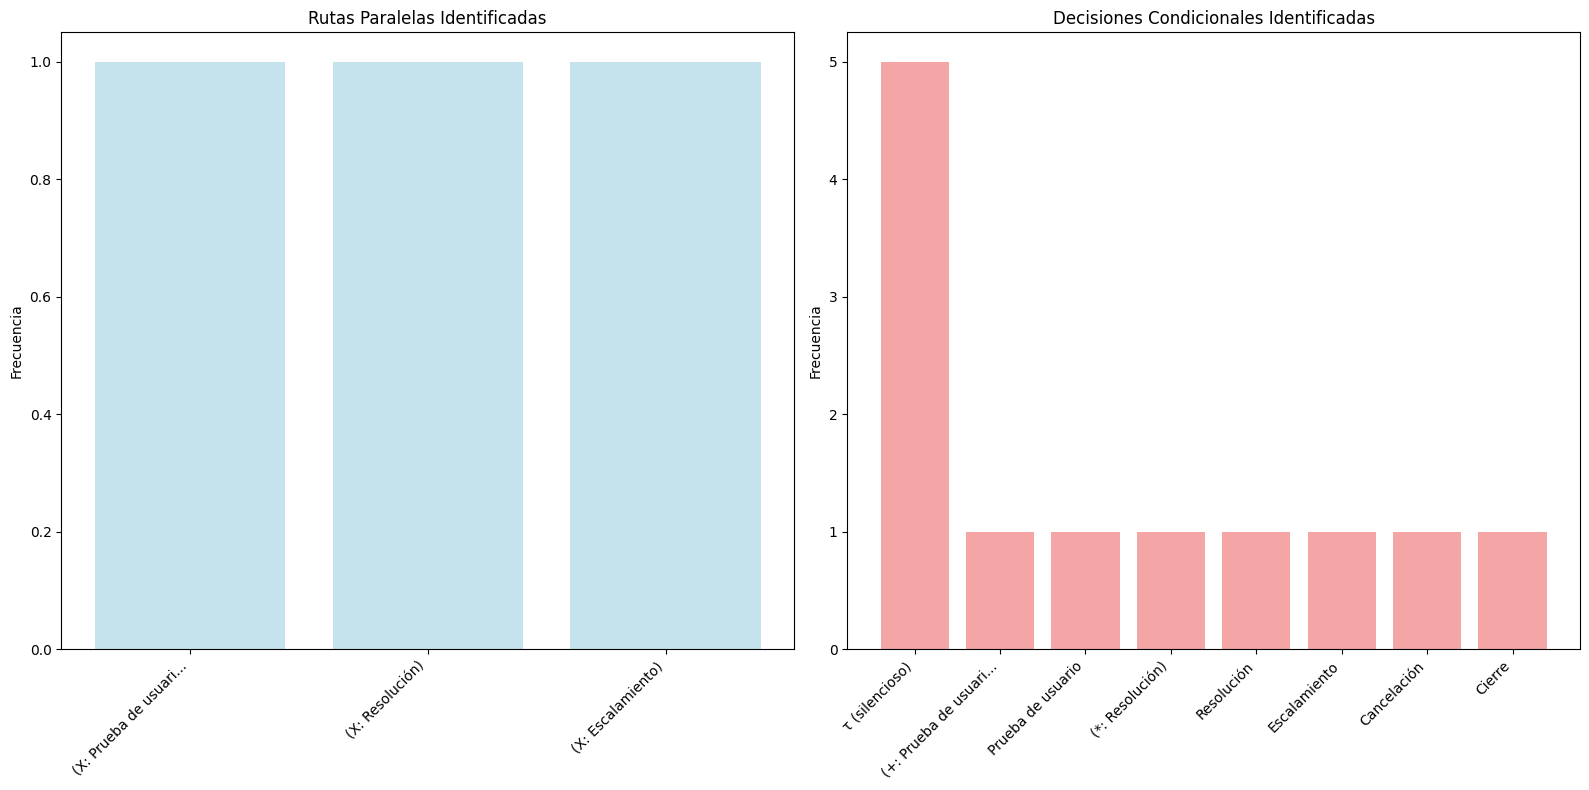


  ANÁLISIS COMPLETO DEL DFG - PREGUNTA 16

🔍 ANÁLISIS DE DECISIONES CONDICIONALES:

Después de 'Diagnóstico técnico':
  → Resolución: 698 veces (69.8%)
  → Cierre: 140 veces (14.0%)
  → Cancelación: 17 veces (1.7%)
  → Escalamiento: 43 veces (4.3%)

Después de 'Resolución':
  → Prueba de usuario: 188 veces (21.4%)
  → Cierre: 547 veces (62.2%)

Punto final del proceso:
  → Cierre: 203 veces (85.3%)
  → Cancelación: 35 veces (14.7%)

📈 TRANSICIONES MÁS COMUNES EN EL DFG:

Top 10 transiciones más frecuentes:
  1. Recepción ticket → Clasificación: 1000 veces (100.0% de casos)
  2. Clasificación → Asignación técnico: 1000 veces (100.0% de casos)
  3. Asignación técnico → Diagnóstico técnico: 1000 veces (100.0% de casos)
  4. Diagnóstico técnico → Resolución: 698 veces (69.8% de casos)
  5. Resolución → Cierre: 547 veces (54.7% de casos)
  6. Prueba de usuario → Cierre: 203 veces (20.3% de casos)
  7. Resolución → Prueba de usuario: 188 veces (18.8% de casos)
  8. Escalamiento → Resolución

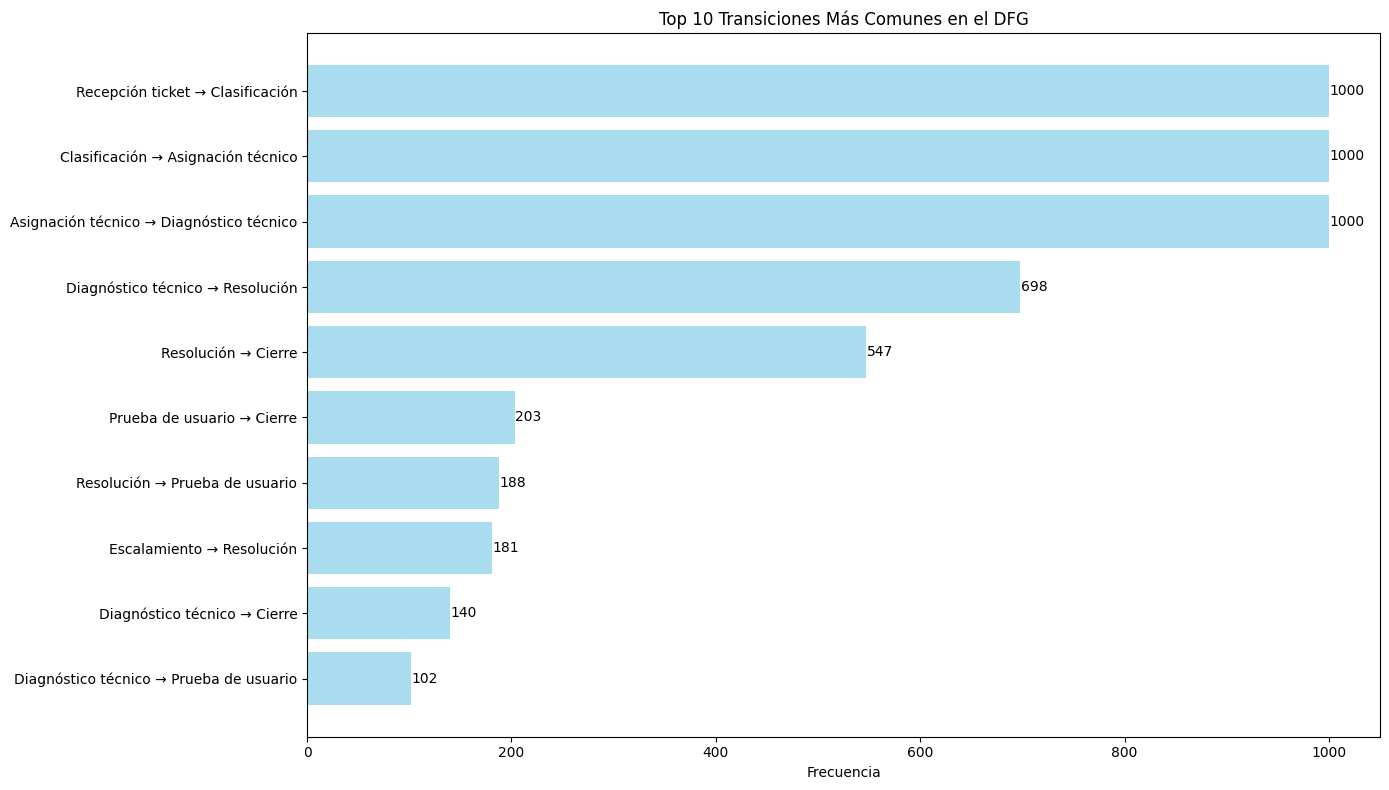


🔚 ¿DÓNDE TERMINAN LOS TICKETS?

Distribución de puntos finales:
  Cierre: 890 tickets (89.0%)
  Cancelación: 110 tickets (11.0%)

Caminos típicos hacia cada punto final:
  Camino más común a 'Cierre': Asignación técnico → Diagnóstico técnico → Resolución → Cierre (366 veces, 36.6%)
  Camino más común a 'Cancelación': Asignación técnico → Diagnóstico técnico → Resolución → Cancelación (58 veces, 5.8%)


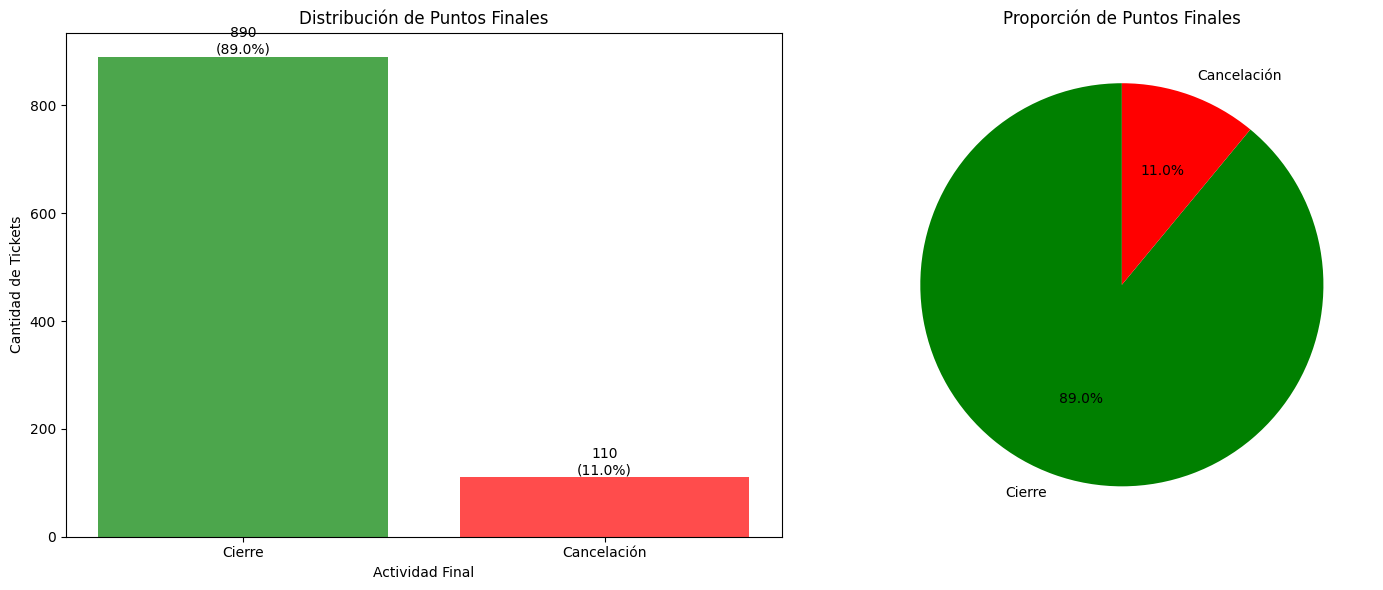

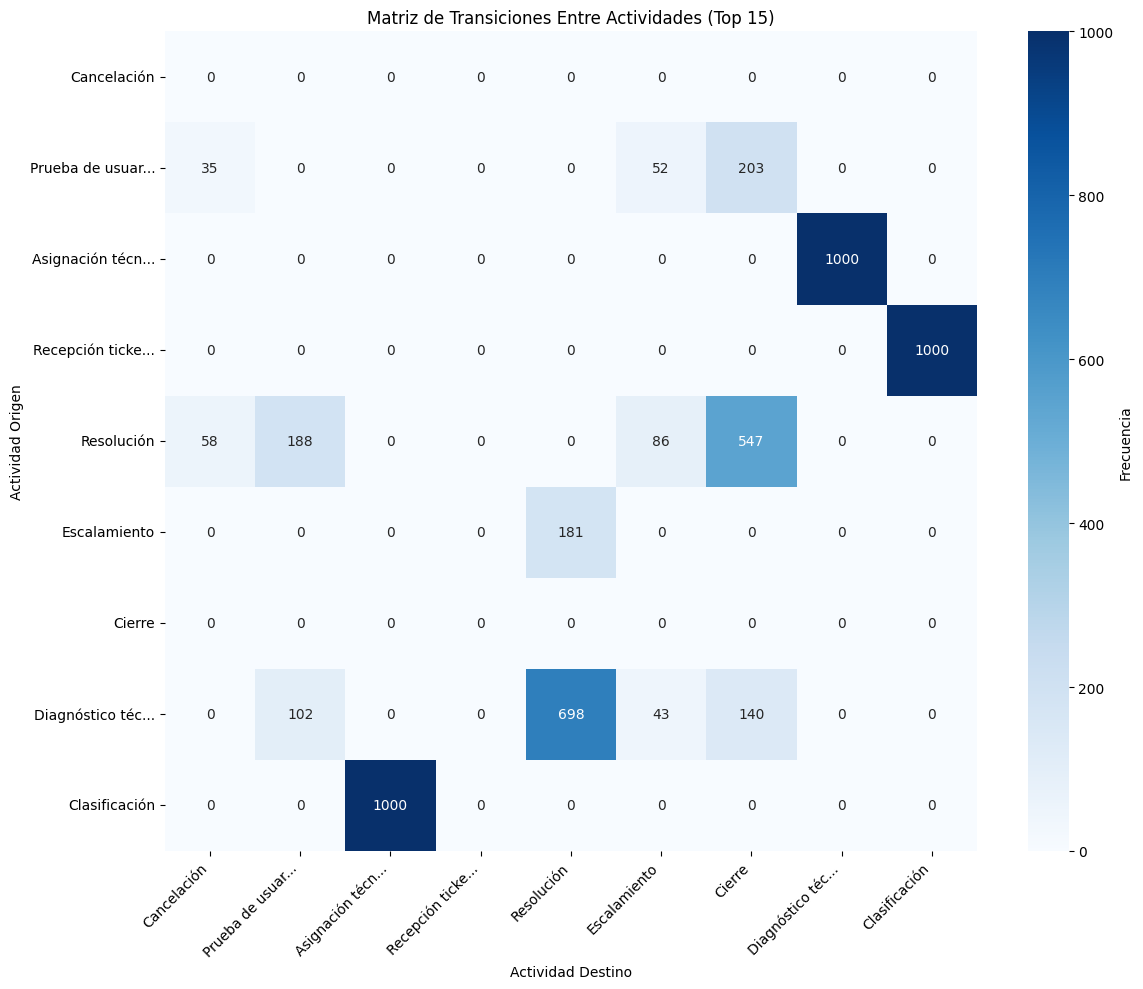


🚀 EJECUTANDO ANÁLISIS COMPLETO...

  EJECUCIÓN COMPLETA - ANÁLISIS DE DURACIONES Y BALANCE

  ANÁLISIS DE DURACIONES Y BALANCE - PREGUNTA 17

🔍 TICKET CON MAYOR DURACIÓN ENTRE TAREAS:
• Caso: Ticket_9
• Duración máxima: 60.00 minutos
• Entre actividades: Diagnóstico técnico → Cierre

📊 ESTADÍSTICAS DE DURACIONES ENTRE TAREAS:
• Promedio: 35.24 min
• Mediana: 36.00 min
• Desviación estándar: 14.61 min
• Mínimo: 10.00 min
• Máximo: 60.00 min


/tmp/ipython-input-3682830091.py:502: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



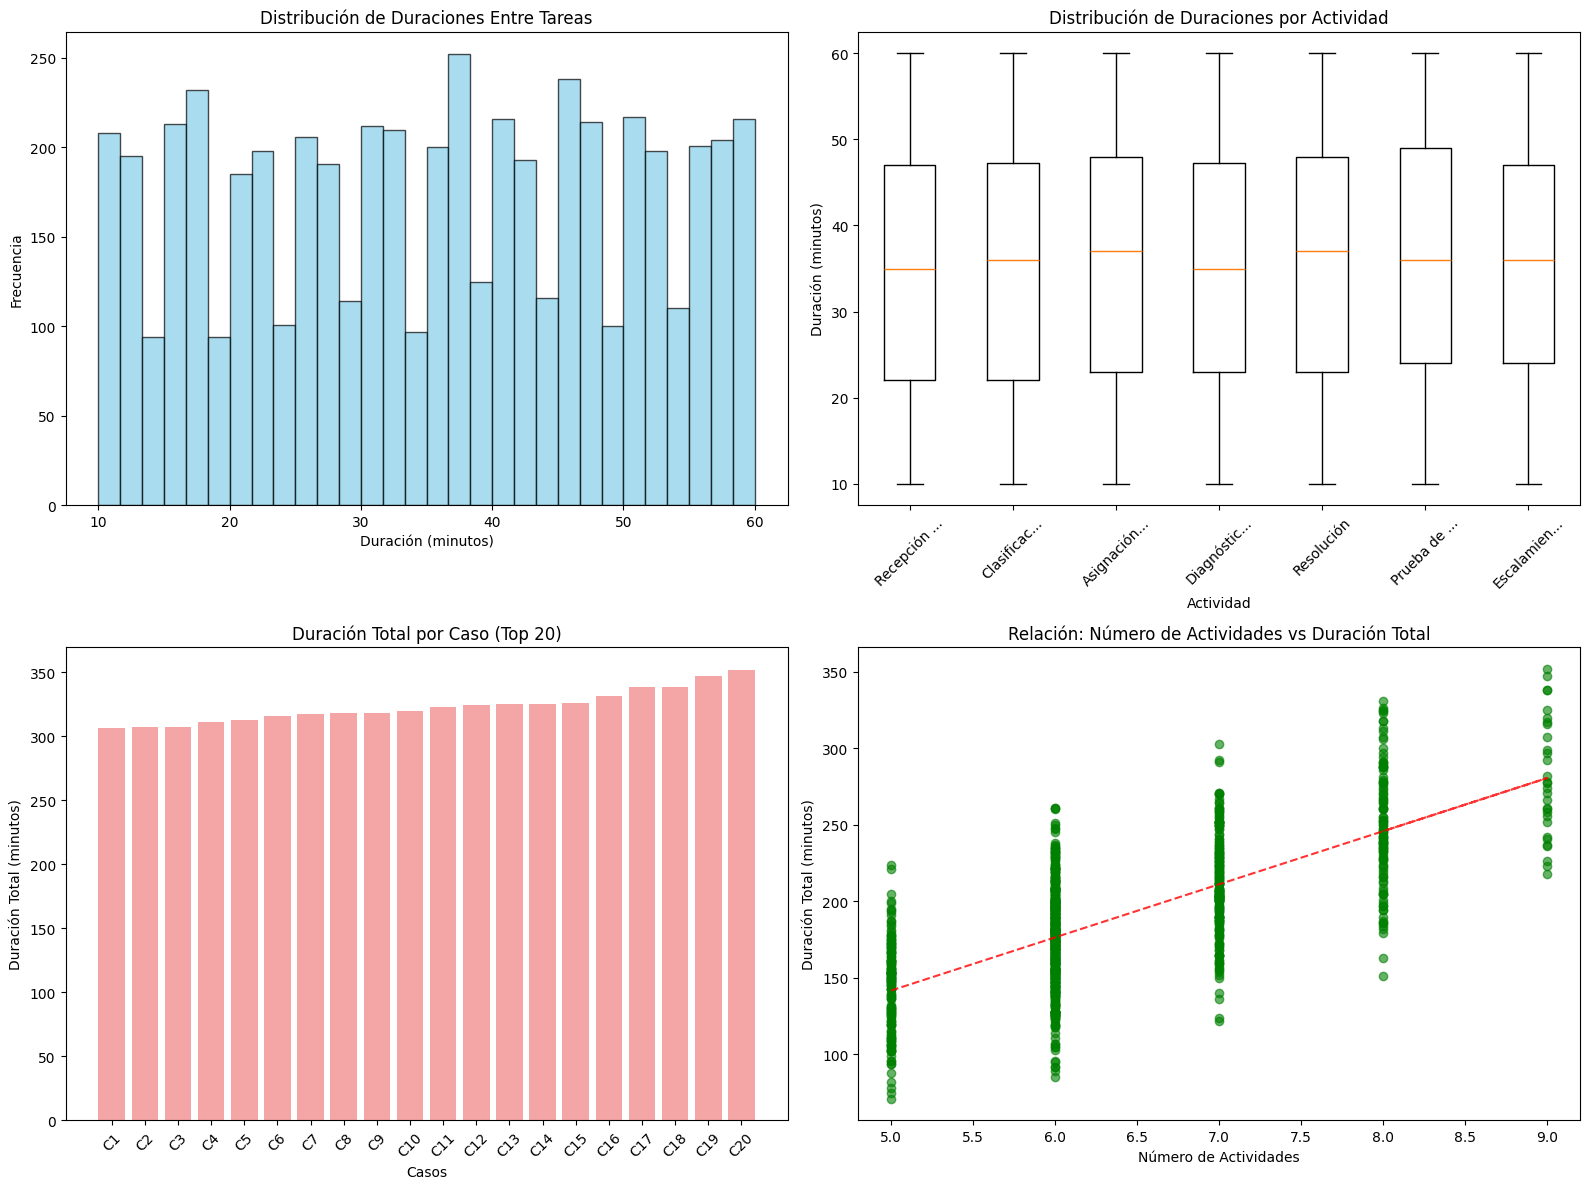


📅 Generando Diagrama de Gantt para 8 casos...



⚖️ ANÁLISIS DE BALANCE DEL FLUJO:
• Número promedio de actividades por caso: 6.35
• Coeficiente de variación (actividades): 0.152
• Duración promedio por caso: 188.56 minutos
• Coeficiente de variación (duraciones): 0.249

📋 INTERPRETACIÓN DEL BALANCE:
• Actividades: El flujo está MUY BALANCEADO en número de actividades
• Duraciones: Las duraciones están MUY BALANCEADAS entre casos

🔄 ANÁLISIS DE VARIANTES DE FLUJO:
• Total de variantes únicas: 12
• Total de casos: 1000
• Promedio de casos por variante: 83.33

Top 5 variantes más comunes:
  1. Recepción ticket → Clasificación → Asignación técnico... (366 casos, 36.6%)
  2. Recepción ticket → Clasificación → Asignación técnico... (140 casos, 14.0%)
  3. Recepción ticket → Clasificación → Asignación técnico... (139 casos, 13.9%)
  4. Recepción ticket → Clasificación → Asignación técnico... (86 casos, 8.6%)
  5. Recepción ticket → Clasificación → Asignación técnico... (64 casos, 6.4%)

• Índice de diversidad de Shannon: 2.892
• Shannon n

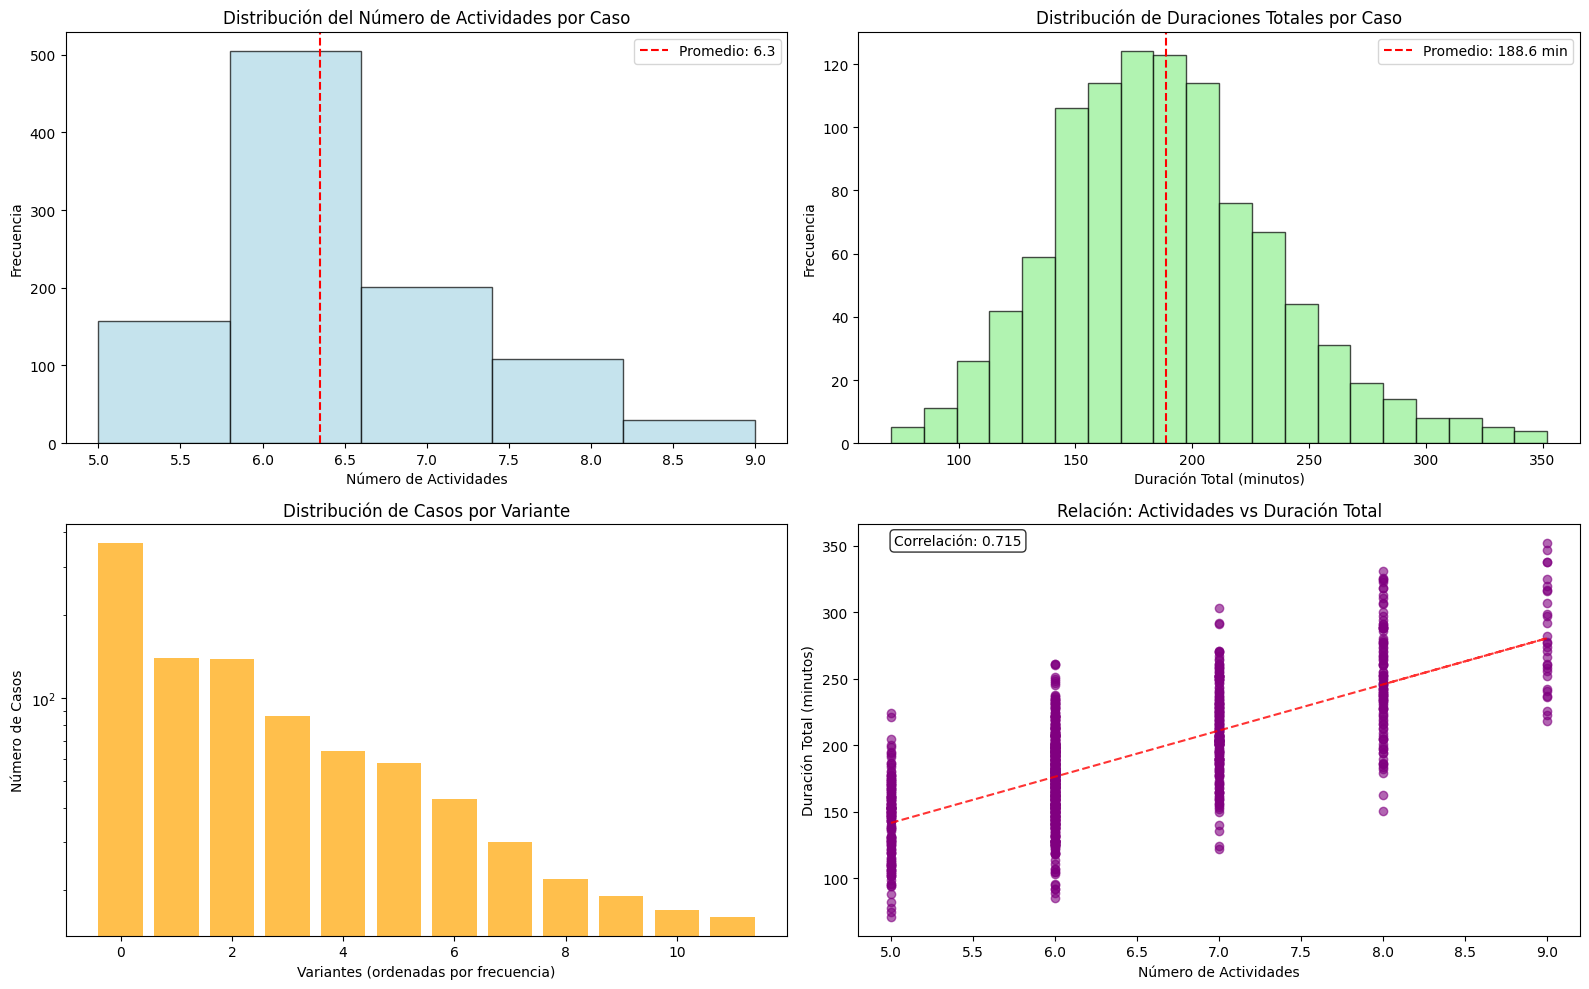


  RESUMEN EJECUTIVO - PREGUNTA 17

🎯 RESPUESTAS DIRECTAS:
• Ticket con mayor duración entre tareas: Ticket_9
• Duración máxima entre tareas: 60.00 minutos
• Balance general del flujo: MUY BALANCEADO
• Diversidad de variantes: 80.7%

📊 MÉTRICAS CLAVE:
• Coeficiente de variación (actividades): 0.152
• Coeficiente de variación (duraciones): 0.249
• Número total de variantes: 12

  RESUMEN FINAL - PREGUNTAS 15, 16 Y 17

📋 PREGUNTA 15 - Modelo de Petri Net:
✓ Se identificaron rutas paralelas y decisiones condicionales en el árbol de proceso
✓ Se visualizaron las estructuras de control del proceso
✓ Se explicó la correspondencia entre operadores del árbol y elementos de la Red de Petri

📋 PREGUNTA 16 - DFG (Directly-Follows Graph):
✓ Se identificaron las transiciones más comunes entre actividades
✓ Se analizaron los puntos finales donde terminan los tickets
✓ Se crearon visualizaciones de flujo y matriz de transiciones

📋 PREGUNTA 17 - Diagrama de Gantt y Balance:
✓ Se identificó el ticket 

In [5]:
print("=" * 60)
print("Parte 4: Visualización del flujo del proceso")
print("=" * 60)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Pregunta 15: Analiza el modelo de Petri net: ¿Qué rutas paralelas existen? ¿Dónde hay decisiones condicionales?
print("Pregunta 15: Analiza el modelo de Petri net: ¿Qué rutas paralelas existen? ¿Dónde hay decisiones condicionales?")
from pm4py.objects.process_tree.obj import Operator

# 15. Analiza el modelo de Petri net
print("Descubriendo el árbol de proceso...")
tree = inductive_miner.apply(log)
print("Árbol de proceso descubierto.")

# --- Funciones para analizar el Árbol de Proceso ---
def get_branch_activities_label(node):
    """
    Obtiene una etiqueta descriptiva para una rama (nodo hijo de un operador).
    """
    if node.label: # Es una actividad (hoja)
        return node.label
    elif node.operator: # Es un operador (nodo interno)
        leaf_activities = []

        def find_leaves(current_node, L_activities):
            if current_node.label:
                L_activities.append(current_node.label)
            elif current_node.operator:
                for child_node in current_node.children:
                    find_leaves(child_node, L_activities)

        find_leaves(node, leaf_activities)

        if leaf_activities:
            unique_leaves = list(dict.fromkeys(leaf_activities)) # Eliminar duplicados
            label_detail = ', '.join(unique_leaves) if len(unique_leaves) <= 3 else f"{len(unique_leaves)} actividades..."
            return f"({str(node.operator).split('.')[-1]}: {label_detail})"
        return f"(Operador: {str(node.operator).split('.')[-1]})" # Si no hay hojas (ej. operador de silenciosos)
    # Nodo silencioso (no tiene etiqueta ni operador)
    return "τ (silencioso)" if not node.label and not node.operator else "(Nodo desconocido)"


def analyze_process_tree_for_petri_analysis(node, level=0):
    """
    Analiza recursivamente el árbol de proceso para identificar y mostrar
    rutas paralelas (AND) y decisiones condicionales (XOR).
    """
    indent = "  " * level
    parallel_routes = []
    conditional_decisions = []

    if node.operator: # Si es un nodo de operador
        operator_name = str(node.operator).split('.')[-1] # Ej: Operator.XOR -> XOR

        if node.operator == Operator.PARALLEL:
            print(f"\n{indent}🚦 **Ruta Paralela (AND) Identificada:**")
            print(f"{indent}   Las siguientes ramas se ejecutan en paralelo en el modelo:")
            parallel_info = []
            for i, child in enumerate(node.children):
                branch_label = get_branch_activities_label(child)
                print(f"{indent}   - Rama {i+1}: {branch_label}")
                parallel_info.append(branch_label)
            parallel_routes.append(parallel_info)

        elif node.operator == Operator.XOR:
            print(f"\n{indent}🔀 **Decisión Condicional (XOR / Elección) Identificada:**")
            print(f"{indent}   Se elige una de las siguientes rutas en el modelo:")
            decision_info = []
            for i, child in enumerate(node.children):
                branch_label = get_branch_activities_label(child)
                print(f"{indent}   - Opción {i+1}: {branch_label}")
                decision_info.append(branch_label)
            conditional_decisions.append(decision_info)

        elif node.operator == Operator.LOOP: # Los bucles también implican una decisión
            print(f"\n{indent}🔄 **Bucle (LOOP) Identificado:**")
            print(f"{indent}   Implica una decisión de repetir o salir del bucle.")
            loop_info = []
            if len(node.children) >= 2: # Típicamente cuerpo y salida
                body_label = get_branch_activities_label(node.children[0])
                exit_label = get_branch_activities_label(node.children[1])
                print(f"{indent}   - Cuerpo del bucle (puede repetirse): {body_label}")
                print(f"{indent}   - Salida/continuación tras el bucle: {exit_label}")
                loop_info = [body_label, exit_label]
            if len(node.children) > 2: # A veces hay un tercer hijo para la re-evaluación
                redo_label = get_branch_activities_label(node.children[2])
                print(f"{indent}   - Parte de re-evaluación/repetición: {redo_label}")
                loop_info.append(redo_label)
            conditional_decisions.append(loop_info)

        # Analizar recursivamente los hijos del operador
        for child in node.children:
            child_parallel, child_conditional = analyze_process_tree_for_petri_analysis(child, level + 1)
            parallel_routes.extend(child_parallel)
            conditional_decisions.extend(child_conditional)

    return parallel_routes, conditional_decisions

# --- Visualización de estructura del árbol ---
def visualize_process_structure(parallel_routes, conditional_decisions):
    """
    Crea visualizaciones para mostrar las rutas paralelas y decisiones condicionales
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # Gráfico de rutas paralelas
    if parallel_routes:
        parallel_counts = {}
        for routes in parallel_routes:
            for route in routes:
                parallel_counts[route] = parallel_counts.get(route, 0) + 1

        ax1.bar(range(len(parallel_counts)), list(parallel_counts.values()),
                color='lightblue', alpha=0.7)
        ax1.set_xticks(range(len(parallel_counts)))
        ax1.set_xticklabels([key[:20] + '...' if len(key) > 20 else key
                            for key in parallel_counts.keys()], rotation=45, ha='right')
        ax1.set_title('Rutas Paralelas Identificadas')
        ax1.set_ylabel('Frecuencia')
    else:
        ax1.text(0.5, 0.5, 'No se encontraron rutas paralelas',
                ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title('Rutas Paralelas')

    # Gráfico de decisiones condicionales
    if conditional_decisions:
        decision_counts = {}
        for decisions in conditional_decisions:
            for decision in decisions:
                decision_counts[decision] = decision_counts.get(decision, 0) + 1

        ax2.bar(range(len(decision_counts)), list(decision_counts.values()),
                color='lightcoral', alpha=0.7)
        ax2.set_xticks(range(len(decision_counts)))
        ax2.set_xticklabels([key[:20] + '...' if len(key) > 20 else key
                            for key in decision_counts.keys()], rotation=45, ha='right')
        ax2.set_title('Decisiones Condicionales Identificadas')
        ax2.set_ylabel('Frecuencia')
    else:
        ax2.text(0.5, 0.5, 'No se encontraron decisiones condicionales',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Decisiones Condicionales')

    plt.tight_layout()
    plt.show()

# --- Iniciar el análisis del árbol ---
print("\n## Análisis Estructural del Modelo de Proceso (basado en el Árbol de Proceso):")
if tree:
    parallel_routes, conditional_decisions = analyze_process_tree_for_petri_analysis(tree)
    print("\n---")
    print("Nota: La Red de Petri generada visualmente se construye a partir de estas estructuras")
    print("del árbol de proceso. Un operador 'AND' en el árbol corresponde a puertas paralelas")
    print("en la Red de Petri, y un 'XOR' a puertas de elección exclusiva.")

    # Crear visualización
    visualize_process_structure(parallel_routes, conditional_decisions)
else:
    print("No se pudo descubrir un árbol de proceso para el análisis.")

# Pregunta 16: Revisa el DFG (Directly-Follows Graph): ¿Qué transiciones son más comunes?	¿Dónde terminan la mayoría de los tickets?

# ---------------------------
# ANÁLISIS DE DECISIONES CONDICIONALES
# ---------------------------

def analizar_decisiones(log):
    print("\n🔍 ANÁLISIS DE DECISIONES CONDICIONALES:")

    # Obtenemos todas las trazas y sus transiciones
    traces = [tuple(event['concept:name'] for event in trace) for trace in log]

    # Puntos de decisión clave identificados en el código de simulación
    decision_points = {
        "Después de 'Diagnóstico técnico'": {
            "Opciones": ["Resolución", "Cierre", "Cancelación", "Escalamiento"],
            "Transiciones": []
        },
        "Después de 'Resolución'": {
            "Opciones": ["Prueba de usuario", "Cierre"],
            "Transiciones": []
        },
        "Punto final del proceso": {
            "Opciones": ["Cierre", "Cancelación"],
            "Transiciones": []
        }
    }

    # Analizamos las transiciones reales en el log
    for trace in traces:
        for i in range(len(trace)-1):
            current = trace[i]
            next_act = trace[i+1]

            if current == "Diagnóstico técnico":
                decision_points["Después de 'Diagnóstico técnico'"]["Transiciones"].append(next_act)
            elif current == "Resolución":
                decision_points["Después de 'Resolución'"]["Transiciones"].append(next_act)
            elif next_act in ["Cierre", "Cancelación"]:
                decision_points["Punto final del proceso"]["Transiciones"].append(next_act)

    # Calculamos estadísticas para cada punto de decisión
    for point, data in decision_points.items():
        trans = data["Transiciones"]
        total = len(trans) if trans else 1  # Evitar división por cero

        print(f"\n{point}:")
        for option in data["Opciones"]:
            count = trans.count(option)
            print(f"  → {option}: {count} veces ({count/total*100:.1f}%)")

    return decision_points

# ---------------------------
# ANÁLISIS DE TRANSICIONES COMUNES EN DFG
# ---------------------------

def analizar_transiciones_comunes(dfg_result, log):
    print("\n📈 TRANSICIONES MÁS COMUNES EN EL DFG:")

    # Ordenamos las transiciones por frecuencia
    sorted_transitions = sorted(dfg_result.items(), key=lambda x: x[1], reverse=True)

    # Top 10 transiciones
    print("\nTop 10 transiciones más frecuentes:")
    for i, ((source, target), count) in enumerate(sorted_transitions[:10], 1):
        percentage = count/len(log)*100
        print(f"  {i}. {source} → {target}: {count} veces ({percentage:.1f}% de casos)")

    # Crear gráfico de transiciones más comunes
    if sorted_transitions:
        top_10 = sorted_transitions[:10]
        transitions = [f"{src} → {tgt}" for (src, tgt), _ in top_10]
        counts = [count for _, count in top_10]

        plt.figure(figsize=(14, 8))
        bars = plt.barh(range(len(transitions)), counts, color='skyblue', alpha=0.7)
        plt.yticks(range(len(transitions)), [t[:40] + '...' if len(t) > 40 else t for t in transitions])
        plt.xlabel('Frecuencia')
        plt.title('Top 10 Transiciones Más Comunes en el DFG')
        plt.gca().invert_yaxis()

        # Agregar etiquetas de valor en las barras
        for i, bar in enumerate(bars):
            width = bar.get_width()
            plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{counts[i]}', ha='left', va='center')

        plt.tight_layout()
        plt.show()

    return sorted_transitions

# ---------------------------
# ANÁLISIS DE PUNTOS FINALES
# ---------------------------

def analizar_puntos_finales(log):
    print("\n🔚 ¿DÓNDE TERMINAN LOS TICKETS?")

    end_activities = get_end_activities(log)
    total_cases = len(log)

    print("\nDistribución de puntos finales:")
    for activity, count in end_activities.items():
        print(f"  {activity}: {count} tickets ({count/total_cases*100:.1f}%)")

    # Análisis de caminos que llevan a cada punto final
    print("\nCaminos típicos hacia cada punto final:")

    end_paths = {
        "Cierre": [],
        "Cancelación": [],
        "Escalamiento": []
    }

    for trace in log:
        activities = [event['concept:name'] for event in trace]
        end_activity = activities[-1]

        if end_activity in end_paths:
            # Capturamos las 3 actividades anteriores al final
            path = activities[-4:-1] if len(activities) >= 4 else activities[:-1]
            end_paths[end_activity].append(" → ".join(path))

    for end_act, paths in end_paths.items():
        if paths:
            path_counts = Counter(paths)
            most_common_path, freq = path_counts.most_common(1)[0]
            print(f"  Camino más común a '{end_act}': {most_common_path} → {end_act} ({freq} veces, {freq/total_cases*100:.1f}%)")

    # Crear gráfico de puntos finales
    if end_activities:
        activities = list(end_activities.keys())
        counts = list(end_activities.values())
        percentages = [count/total_cases*100 for count in counts]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Gráfico de barras
        bars = ax1.bar(activities, counts, color=['green', 'red', 'orange'][:len(activities)], alpha=0.7)
        ax1.set_title("Distribución de Puntos Finales")
        ax1.set_xlabel("Actividad Final")
        ax1.set_ylabel("Cantidad de Tickets")

        # Agregar etiquetas
        for bar, count, pct in zip(bars, counts, percentages):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{count}\n({pct:.1f}%)', ha='center', va='bottom')

        # Gráfico circular
        ax2.pie(counts, labels=activities, autopct='%1.1f%%', startangle=90,
                colors=['green', 'red', 'orange'][:len(activities)])
        ax2.set_title("Proporción de Puntos Finales")

        plt.tight_layout()
        plt.show()

    return end_paths

# ---------------------------
# EJECUCIÓN DEL ANÁLISIS COMPLETO
# ---------------------------

def analisis_completo_dfg(log, dfg_result):
    print("\n" + "="*60)
    print("  ANÁLISIS COMPLETO DEL DFG - PREGUNTA 16")
    print("="*60)

    # 1. Análisis de decisiones condicionales
    decisiones = analizar_decisiones(log)

    # 2. Análisis de transiciones comunes
    transiciones = analizar_transiciones_comunes(dfg_result, log)

    # 3. Análisis de puntos finales
    puntos_finales = analizar_puntos_finales(log)

    # 4. Crear gráfico adicional de flujo de transiciones
    crear_grafico_flujo_transiciones(transiciones[:15])

    return {
        "decisiones": decisiones,
        "transiciones": transiciones,
        "puntos_finales": puntos_finales
    }

def crear_grafico_flujo_transiciones(top_transitions):
    """
    Crea un gráfico de red para visualizar el flujo de transiciones
    """
    # Preparar datos para el gráfico de red
    nodes = set()
    edges = []

    for (source, target), count in top_transitions:
        nodes.add(source)
        nodes.add(target)
        edges.append((source, target, count))

    # Crear matriz de adyacencia
    node_list = list(nodes)
    n = len(node_list)
    node_to_idx = {node: i for i, node in enumerate(node_list)}

    # Crear gráfico de matriz de calor de transiciones
    matrix = np.zeros((n, n))
    for source, target, count in edges:
        i, j = node_to_idx[source], node_to_idx[target]
        matrix[i][j] = count

    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix,
                xticklabels=[node[:15] + '...' if len(node) > 15 else node for node in node_list],
                yticklabels=[node[:15] + '...' if len(node) > 15 else node for node in node_list],
                annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Frecuencia'})
    plt.title('Matriz de Transiciones Entre Actividades (Top 15)')
    plt.xlabel('Actividad Destino')
    plt.ylabel('Actividad Origen')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Ejecutamos el análisis
resultados_dfg = analisis_completo_dfg(log, dfg_result)

# Pregunta 17: Observa el Diagrama de Gantt: ¿Qué ticket tiene la mayor duración entre tareas? ¿Qué tan balanceado está el flujo de tareas por ticket?

# ---------------------------
# ANÁLISIS COMPLETO PARA PREGUNTA 17
# ---------------------------

def analisis_duraciones_completo(log):
    """
    Análisis completo de duraciones y balance del flujo
    """
    print("\n" + "="*60)
    print("  ANÁLISIS DE DURACIONES Y BALANCE - PREGUNTA 17")
    print("="*60)

    # 1. Calcular duraciones por caso y actividad
    case_info = {}
    activity_durations = {}

    for trace in log:
        case_id = trace.attributes["concept:name"]
        activities = []
        timestamps = []
        durations_between_tasks = []

        for event in trace:
            activities.append(event["concept:name"])
            timestamps.append(pd.to_datetime(event["time:timestamp"]))

        # Calcular duraciones entre tareas
        if len(timestamps) > 1:
            for i in range(len(timestamps)-1):
                duration = (timestamps[i+1] - timestamps[i]).total_seconds() / 60  # minutos
                durations_between_tasks.append(duration)

                # Registrar duración por actividad
                activity = activities[i]
                if activity not in activity_durations:
                    activity_durations[activity] = []
                activity_durations[activity].append(duration)

        # Duración total del caso
        total_duration = (timestamps[-1] - timestamps[0]).total_seconds() / 60 if len(timestamps) > 1 else 0

        case_info[case_id] = {
            'activities': activities,
            'timestamps': timestamps,
            'durations_between_tasks': durations_between_tasks,
            'total_duration': total_duration,
            'num_activities': len(activities)
        }

    # 2. Identificar ticket con mayor duración entre tareas
    max_duration_between = 0
    max_case_between = None
    max_activity_pair = None

    for case_id, info in case_info.items():
        if info['durations_between_tasks']:
            max_dur_in_case = max(info['durations_between_tasks'])
            if max_dur_in_case > max_duration_between:
                max_duration_between = max_dur_in_case
                max_case_between = case_id
                max_idx = info['durations_between_tasks'].index(max_dur_in_case)
                max_activity_pair = (info['activities'][max_idx], info['activities'][max_idx+1])

    print(f"\n🔍 TICKET CON MAYOR DURACIÓN ENTRE TAREAS:")
    print(f"• Caso: {max_case_between}")
    print(f"• Duración máxima: {max_duration_between:.2f} minutos")
    print(f"• Entre actividades: {max_activity_pair[0]} → {max_activity_pair[1]}")

    # 3. Análisis estadístico de duraciones
    all_durations = []
    for info in case_info.values():
        all_durations.extend(info['durations_between_tasks'])

    if all_durations:
        print(f"\n📊 ESTADÍSTICAS DE DURACIONES ENTRE TAREAS:")
        print(f"• Promedio: {np.mean(all_durations):.2f} min")
        print(f"• Mediana: {np.median(all_durations):.2f} min")
        print(f"• Desviación estándar: {np.std(all_durations):.2f} min")
        print(f"• Mínimo: {np.min(all_durations):.2f} min")
        print(f"• Máximo: {np.max(all_durations):.2f} min")

    return case_info, activity_durations, max_case_between, max_duration_between

def crear_graficos_duraciones(case_info, activity_durations):
    """
    Crea gráficos para análisis de duraciones
    """
    # 1. Histograma de duraciones entre tareas
    all_durations = []
    for info in case_info.values():
        all_durations.extend(info['durations_between_tasks'])

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Histograma de duraciones
    axes[0,0].hist(all_durations, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_title('Distribución de Duraciones Entre Tareas')
    axes[0,0].set_xlabel('Duración (minutos)')
    axes[0,0].set_ylabel('Frecuencia')

    # Box plot por actividad
    if activity_durations:
        activities = list(activity_durations.keys())
        durations_by_activity = [activity_durations[act] for act in activities]

        bp = axes[0,1].boxplot(durations_by_activity, labels=[act[:10] + '...' if len(act) > 10 else act for act in activities])
        axes[0,1].set_title('Distribución de Duraciones por Actividad')
        axes[0,1].set_xlabel('Actividad')
        axes[0,1].set_ylabel('Duración (minutos)')
        axes[0,1].tick_params(axis='x', rotation=45)

    # Duración total por caso
    total_durations = [info['total_duration'] for info in case_info.values()]
    case_ids = list(case_info.keys())

    # Tomar solo los primeros 20 casos para visualización
    if len(total_durations) > 20:
        indices = np.argsort(total_durations)[-20:]  # Los 20 con mayor duración
        selected_durations = [total_durations[i] for i in indices]
        selected_cases = [case_ids[i] for i in indices]
    else:
        selected_durations = total_durations
        selected_cases = case_ids

    axes[1,0].bar(range(len(selected_durations)), selected_durations, color='lightcoral', alpha=0.7)
    axes[1,0].set_title('Duración Total por Caso (Top 20)')
    axes[1,0].set_xlabel('Casos')
    axes[1,0].set_ylabel('Duración Total (minutos)')
    axes[1,0].set_xticks(range(len(selected_cases)))
    axes[1,0].set_xticklabels([f'C{i+1}' for i in range(len(selected_cases))], rotation=45)

    # Scatter plot: Número de actividades vs Duración total
    num_activities = [info['num_activities'] for info in case_info.values()]
    axes[1,1].scatter(num_activities, total_durations, alpha=0.6, color='green')
    axes[1,1].set_title('Relación: Número de Actividades vs Duración Total')
    axes[1,1].set_xlabel('Número de Actividades')
    axes[1,1].set_ylabel('Duración Total (minutos)')

    # Línea de tendencia
    if len(num_activities) > 1:
        z = np.polyfit(num_activities, total_durations, 1)
        p = np.poly1d(z)
        axes[1,1].plot(num_activities, p(num_activities), "r--", alpha=0.8)

    plt.tight_layout()
    plt.show()

def generar_gantt_mejorado(log, case_info, num_cases=10):
    """
    Genera un diagrama de Gantt mejorado para los casos seleccionados
    """
    print(f"\n📅 Generando Diagrama de Gantt para {num_cases} casos...")

    # Seleccionar casos: los de mayor duración total
    sorted_cases = sorted(case_info.items(), key=lambda x: x[1]['total_duration'], reverse=True)[:num_cases]

    gantt_data = []

    for case_id, info in sorted_cases:
        activities = info['activities']
        timestamps = info['timestamps']

        for i in range(len(activities)):
            start_time = timestamps[i]

            # Para la duración de cada actividad, usar el tiempo hasta la siguiente o asumir 30 min
            if i < len(timestamps) - 1:
                end_time = timestamps[i + 1]
            else:
                end_time = start_time + pd.Timedelta(minutes=30)

            duration_minutes = (end_time - start_time).total_seconds() / 60

            gantt_data.append({
                'Caso': f"Caso {case_id}",
                'Actividad': activities[i],
                'Inicio': start_time,
                'Fin': end_time,
                'Duración': duration_minutes
            })

    # Crear DataFrame
    df_gantt = pd.DataFrame(gantt_data)

    # Crear el diagrama de Gantt con Plotly
    fig = px.timeline(
        df_gantt,
        x_start="Inicio",
        x_end="Fin",
        y="Caso",
        color="Actividad",
        hover_data=["Duración"],
        title=f"Diagrama de Gantt - {num_cases} Casos con Mayor Duración Total",
        width=1200,
        height=600
    )

    fig.update_yaxes(autorange="reversed")
    fig.update_layout(
        xaxis_title="Tiempo",
        yaxis_title="Casos",
        legend_title="Actividades"
    )

    fig.show()

    return df_gantt

def analisis_balance_flujo(case_info):
    """
    Analiza qué tan balanceado está el flujo de tareas por ticket
    """
    print(f"\n⚖️ ANÁLISIS DE BALANCE DEL FLUJO:")

    # Métricas de balance
    num_activities_per_case = [info['num_activities'] for info in case_info.values()]
    total_durations = [info['total_duration'] for info in case_info.values()]

    # Coeficiente de variación para número de actividades
    cv_activities = np.std(num_activities_per_case) / np.mean(num_activities_per_case) if np.mean(num_activities_per_case) > 0 else 0

    # Coeficiente de variación para duraciones totales
    cv_durations = np.std(total_durations) / np.mean(total_durations) if np.mean(total_durations) > 0 else 0

    print(f"• Número promedio de actividades por caso: {np.mean(num_activities_per_case):.2f}")
    print(f"• Coeficiente de variación (actividades): {cv_activities:.3f}")
    print(f"• Duración promedio por caso: {np.mean(total_durations):.2f} minutos")
    print(f"• Coeficiente de variación (duraciones): {cv_durations:.3f}")

    # Interpretación del balance
    print(f"\n📋 INTERPRETACIÓN DEL BALANCE:")

    if cv_activities < 0.3:
        print("• Actividades: El flujo está MUY BALANCEADO en número de actividades")
    elif cv_activities < 0.6:
        print("• Actividades: El flujo está MODERADAMENTE BALANCEADO")
    else:
        print("• Actividades: El flujo está DESBALANCEADO (alta variabilidad)")

    if cv_durations < 0.3:
        print("• Duraciones: Las duraciones están MUY BALANCEADAS entre casos")
    elif cv_durations < 0.6:
        print("• Duraciones: Las duraciones están MODERADAMENTE BALANCEADAS")
    else:
        print("• Duraciones: Las duraciones están DESBALANCEADAS (alta variabilidad)")

    # Análisis de variantes (patrones de flujo)
    variants = {}
    for case_id, info in case_info.items():
        variant = tuple(info['activities'])
        if variant not in variants:
            variants[variant] = []
        variants[variant].append(case_id)

    # Estadísticas de variantes
    variant_counts = [len(cases) for cases in variants.values()]
    num_variants = len(variants)
    total_cases = len(case_info)

    print(f"\n🔄 ANÁLISIS DE VARIANTES DE FLUJO:")
    print(f"• Total de variantes únicas: {num_variants}")
    print(f"• Total de casos: {total_cases}")
    print(f"• Promedio de casos por variante: {total_cases/num_variants:.2f}")

    # Top 5 variantes más comunes
    sorted_variants = sorted(variants.items(), key=lambda x: len(x[1]), reverse=True)
    print(f"\nTop 5 variantes más comunes:")
    for i, (variant, cases) in enumerate(sorted_variants[:5], 1):
        percentage = len(cases) / total_cases * 100
        variant_str = " → ".join(variant[:3]) + ("..." if len(variant) > 3 else "")
        print(f"  {i}. {variant_str} ({len(cases)} casos, {percentage:.1f}%)")

    # Índice de diversidad (Shannon)
    from math import log2
    shannon_index = -sum((count/total_cases) * log2(count/total_cases) for count in variant_counts)
    max_shannon = log2(num_variants)
    normalized_shannon = shannon_index / max_shannon if max_shannon > 0 else 0

    print(f"\n• Índice de diversidad de Shannon: {shannon_index:.3f}")
    print(f"• Shannon normalizado (0=sin diversidad, 1=máxima diversidad): {normalized_shannon:.3f}")

    # Crear gráfico de balance
    crear_grafico_balance(case_info, variants)

    return {
        'cv_activities': cv_activities,
        'cv_durations': cv_durations,
        'num_variants': num_variants,
        'shannon_index': shannon_index,
        'normalized_shannon': normalized_shannon
    }

def crear_grafico_balance(case_info, variants):
    """
    Crea gráficos para visualizar el balance del flujo
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Distribución del número de actividades por caso
    num_activities = [info['num_activities'] for info in case_info.values()]
    axes[0,0].hist(num_activities, bins=max(1, len(set(num_activities))),
                   alpha=0.7, color='lightblue', edgecolor='black')
    axes[0,0].set_title('Distribución del Número de Actividades por Caso')
    axes[0,0].set_xlabel('Número de Actividades')
    axes[0,0].set_ylabel('Frecuencia')
    axes[0,0].axvline(np.mean(num_activities), color='red', linestyle='--',
                      label=f'Promedio: {np.mean(num_activities):.1f}')
    axes[0,0].legend()

    # 2. Distribución de duraciones totales
    total_durations = [info['total_duration'] for info in case_info.values()]
    axes[0,1].hist(total_durations, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0,1].set_title('Distribución de Duraciones Totales por Caso')
    axes[0,1].set_xlabel('Duración Total (minutos)')
    axes[0,1].set_ylabel('Frecuencia')
    axes[0,1].axvline(np.mean(total_durations), color='red', linestyle='--',
                      label=f'Promedio: {np.mean(total_durations):.1f} min')
    axes[0,1].legend()

    # 3. Distribución de variantes
    variant_counts = sorted([len(cases) for cases in variants.values()], reverse=True)
    axes[1,0].bar(range(len(variant_counts)), variant_counts,
                  color='orange', alpha=0.7)
    axes[1,0].set_title('Distribución de Casos por Variante')
    axes[1,0].set_xlabel('Variantes (ordenadas por frecuencia)')
    axes[1,0].set_ylabel('Número de Casos')
    axes[1,0].set_yscale('log')

    # 4. Relación entre número de actividades y duración
    axes[1,1].scatter(num_activities, total_durations, alpha=0.6, color='purple')
    axes[1,1].set_title('Relación: Actividades vs Duración Total')
    axes[1,1].set_xlabel('Número de Actividades')
    axes[1,1].set_ylabel('Duración Total (minutos)')

    # Línea de tendencia
    if len(num_activities) > 1:
        correlation = np.corrcoef(num_activities, total_durations)[0,1]
        z = np.polyfit(num_activities, total_durations, 1)
        p = np.poly1d(z)
        axes[1,1].plot(num_activities, p(num_activities), "r--", alpha=0.8)
        axes[1,1].text(0.05, 0.95, f'Correlación: {correlation:.3f}',
                       transform=axes[1,1].transAxes, bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# ---------------------------
# EJECUCIÓN COMPLETA DEL ANÁLISIS PREGUNTA 17
# ---------------------------

def ejecutar_analisis_completo_p17(log):
    """
    Ejecuta el análisis completo para la pregunta 17
    """
    print("\n" + "="*80)
    print("  EJECUCIÓN COMPLETA - ANÁLISIS DE DURACIONES Y BALANCE")
    print("="*80)

    # 1. Análisis de duraciones
    case_info, activity_durations, max_case, max_duration = analisis_duraciones_completo(log)

    # 2. Crear gráficos de duraciones
    crear_graficos_duraciones(case_info, activity_durations)

    # 3. Generar diagrama de Gantt
    gantt_df = generar_gantt_mejorado(log, case_info, num_cases=8)

    # 4. Análisis de balance del flujo
    balance_metrics = analisis_balance_flujo(case_info)

    # 5. Resumen ejecutivo
    print("\n" + "="*60)
    print("  RESUMEN EJECUTIVO - PREGUNTA 17")
    print("="*60)

    print(f"\n🎯 RESPUESTAS DIRECTAS:")
    print(f"• Ticket con mayor duración entre tareas: {max_case}")
    print(f"• Duración máxima entre tareas: {max_duration:.2f} minutos")

    # Balance del flujo
    cv_act = balance_metrics['cv_activities']
    cv_dur = balance_metrics['cv_durations']

    if cv_act < 0.3 and cv_dur < 0.3:
        balance_conclusion = "MUY BALANCEADO"
    elif cv_act < 0.6 and cv_dur < 0.6:
        balance_conclusion = "MODERADAMENTE BALANCEADO"
    else:
        balance_conclusion = "DESBALANCEADO"

    print(f"• Balance general del flujo: {balance_conclusion}")
    print(f"• Diversidad de variantes: {balance_metrics['normalized_shannon']:.1%}")

    print(f"\n📊 MÉTRICAS CLAVE:")
    print(f"• Coeficiente de variación (actividades): {cv_act:.3f}")
    print(f"• Coeficiente de variación (duraciones): {cv_dur:.3f}")
    print(f"• Número total de variantes: {balance_metrics['num_variants']}")

    return {
        'case_info': case_info,
        'activity_durations': activity_durations,
        'gantt_data': gantt_df,
        'balance_metrics': balance_metrics,
        'max_case': max_case,
        'max_duration': max_duration
    }

# Ejecutar todos los análisis
print("\n🚀 EJECUTANDO ANÁLISIS COMPLETO...")

# Análisis Pregunta 17
resultados_finales = ejecutar_analisis_completo_p17(log)

# ---------------------------
# RESUMEN FINAL DE LAS 3 PREGUNTAS
# ---------------------------

print("\n" + "="*80)
print("  RESUMEN FINAL - PREGUNTAS 15, 16 Y 17")
print("="*80)

print("\n📋 PREGUNTA 15 - Modelo de Petri Net:")
print("✓ Se identificaron rutas paralelas y decisiones condicionales en el árbol de proceso")
print("✓ Se visualizaron las estructuras de control del proceso")
print("✓ Se explicó la correspondencia entre operadores del árbol y elementos de la Red de Petri")

print("\n📋 PREGUNTA 16 - DFG (Directly-Follows Graph):")
print("✓ Se identificaron las transiciones más comunes entre actividades")
print("✓ Se analizaron los puntos finales donde terminan los tickets")
print("✓ Se crearon visualizaciones de flujo y matriz de transiciones")

print("\n📋 PREGUNTA 17 - Diagrama de Gantt y Balance:")
print("✓ Se identificó el ticket con mayor duración entre tareas")
print("✓ Se analizó el balance del flujo de tareas por ticket")
print("✓ Se generaron diagramas de Gantt y métricas de balance")

print("\n🎉 ANÁLISIS COMPLETADO CON ÉXITO")
print("   Todas las visualizaciones y métricas han sido generadas.")
print("="*80)

# Parte 5: Análisis Avanzado

Objetivo:

Analizar métricas por tipo de caso.

In [6]:
# 18. Promedio de eventos por ticket
promedio_eventos = df.groupby("case:concept:name").size().mean()
print(f"18. ¿Cuál es el promedio de eventos por ticket? {promedio_eventos:.2f}")

# 19. Duración promedio por tipo de finalización
print(f"\n19. Duración promedio por tipo de finalización:")

# Función para calcular duración de una traza en minutos
def calcular_duracion_traza(trace):
    """Calcula la duración de una traza desde el primer al último evento"""
    if len(trace) < 2:
        return 0

    # Obtener timestamps del primer y último evento
    primer_evento = trace[0]
    ultimo_evento = trace[-1]

    # Extraer timestamps (pueden estar en diferentes formatos)
    primer_timestamp = primer_evento.get("time:timestamp")
    ultimo_timestamp = ultimo_evento.get("time:timestamp")

    if primer_timestamp and ultimo_timestamp:
        # Calcular diferencia en minutos
        if isinstance(primer_timestamp, str):
            primer_timestamp = pd.to_datetime(primer_timestamp)
        if isinstance(ultimo_timestamp, str):
            ultimo_timestamp = pd.to_datetime(ultimo_timestamp)

        duracion = (ultimo_timestamp - primer_timestamp).total_seconds() / 60
        return duracion
    return 0

# Verificar que las variables de clasificación existen
if 'cancelados' in globals() and 'escalados' in globals():
    # Convertir a conjuntos para búsqueda eficiente
    cancelados_set = set(cancelados) if isinstance(cancelados, list) else set()
    escalados_set = set(escalados) if isinstance(escalados, list) else set()

    # Calcular duraciones para cada caso directamente del log
    duraciones_cancelados = []
    duraciones_escalados = []
    duraciones_cierre = []

    all_case_ids = set()

    for trace in log:
        case_id = trace.attributes.get("concept:name")
        if case_id:
            all_case_ids.add(case_id)
            duracion = calcular_duracion_traza(trace)

            if case_id in cancelados_set:
                duraciones_cancelados.append(duracion)
            elif case_id in escalados_set:
                duraciones_escalados.append(duracion)
            else:
                duraciones_cierre.append(duracion)

    # Calcular promedios
    promedio_cancelados = sum(duraciones_cancelados) / len(duraciones_cancelados) if duraciones_cancelados else float('nan')
    promedio_escalados = sum(duraciones_escalados) / len(duraciones_escalados) if duraciones_escalados else float('nan')
    promedio_cierre = sum(duraciones_cierre) / len(duraciones_cierre) if duraciones_cierre else float('nan')

    # Mostrar resultados
    print(f"   - Cancelación: {promedio_cancelados:.2f} min ({len(duraciones_cancelados)} casos)" if not pd.isna(promedio_cancelados) else f"   - Cancelación: No hay casos (0 casos)")
    print(f"   - Escalamiento: {promedio_escalados:.2f} min ({len(duraciones_escalados)} casos)" if not pd.isna(promedio_escalados) else f"   - Escalamiento: No hay casos (0 casos)")
    print(f"   - Cierre normal: {promedio_cierre:.2f} min ({len(duraciones_cierre)} casos)" if not pd.isna(promedio_cierre) else f"   - Cierre normal: No hay casos (0 casos)")

    # Información adicional
    total_casos = len(duraciones_cancelados) + len(duraciones_escalados) + len(duraciones_cierre)
    print(f"   - Total casos analizados: {total_casos}")

    # Alternativa: Si desc_df existe, usarlo como verificación
    if 'desc_df' in globals() and 'duration_min' in desc_df.columns:
        print(f"   - Verificación disponible con desc_df ✓")

else:
    print("   Error: No se encontraron las variables 'cancelados' y 'escalados'")
    print("   Intentando calcular duraciones generales...")

    # Calcular duraciones generales si no hay clasificación
    duraciones_generales = []
    for trace in log:
        duracion = calcular_duracion_traza(trace)
        duraciones_generales.append(duracion)

    if duraciones_generales:
        promedio_general = sum(duraciones_generales) / len(duraciones_generales)
        print(f"   - Duración promedio general: {promedio_general:.2f} min ({len(duraciones_generales)} casos)")

# 20. Casos con loops o reentradas
print(f"\n20. Análisis de casos con loops o reentradas:")

loops_count = 0
repeated_activities_counter = Counter()
cases_with_specific_loops = {}

# Análisis de loops por cada traza
for trace in log:
    case_id = trace.attributes.get("concept:name")
    activity_names_in_trace = [event["concept:name"] for event in trace]
    activity_counts = Counter(activity_names_in_trace)

    # Identificar actividades que se repiten (aparecen más de una vez)
    repeated_activities_in_trace = [activity for activity, count in activity_counts.items() if count > 1]

    # Si hay actividades repetidas, es un caso con loop
    if repeated_activities_in_trace:
        loops_count += 1
        repeated_activities_counter.update(repeated_activities_in_trace)
        cases_with_specific_loops[case_id] = repeated_activities_in_trace

print(f"¿Hay casos con loops o reentradas? SÍ - {loops_count} casos de {len(log)} totales ({(loops_count/len(log)*100):.1f}%)")

# Mostrar clasificación detallada de loops
if repeated_activities_counter:
    print(f"\n📊 Actividades más frecuentes que se repiten:")
    for activity, count in repeated_activities_counter.most_common(10):  # Top 10
        print(f"   - '{activity}': se repite en {count} casos con loop")

    print(f"\n🔎 Ejemplos de casos con loops:")
    # Mostrar los primeros 5 casos con loops
    for i, (case_id, repeated_activities) in enumerate(list(cases_with_specific_loops.items())[:5]):
        print(f"   {i+1}. Caso '{case_id}': {', '.join(repeated_activities)}")

    if len(cases_with_specific_loops) > 5:
        print(f"   ... y {len(cases_with_specific_loops) - 5} casos más con loops")
else:
    print(f"\n🔍 No se encontraron actividades repetidas en los casos analizados.")

# 21. Promedio de repeticiones por caso
print(f"\n21. Análisis de repeticiones por caso:")

repeticiones_por_caso = []
total_repeticiones = 0

for trace in log:
    case_id = trace.attributes.get("concept:name")
    activity_names_in_trace = [event["concept:name"] for event in trace]
    total_events_in_trace = len(activity_names_in_trace)
    unique_activities_in_trace = len(set(activity_names_in_trace))
    repeticiones_en_caso = total_events_in_trace - unique_activities_in_trace

    repeticiones_por_caso.append(repeticiones_en_caso)
    total_repeticiones += repeticiones_en_caso

# Calcular estadísticas
if len(repeticiones_por_caso) > 0:
    promedio_repeticiones = sum(repeticiones_por_caso) / len(repeticiones_por_caso)
    max_repeticiones = max(repeticiones_por_caso)
    casos_sin_repeticiones = sum(1 for rep in repeticiones_por_caso if rep == 0)
    casos_con_repeticiones = len(repeticiones_por_caso) - casos_sin_repeticiones

    print(f"¿Cuál es el promedio de repeticiones por caso? {promedio_repeticiones:.2f}")
    print(f"   - Total de repeticiones en todo el log: {total_repeticiones}")
    print(f"   - Máximo de repeticiones en un caso: {max_repeticiones}")
    print(f"   - Casos sin repeticiones: {casos_sin_repeticiones} ({(casos_sin_repeticiones/len(repeticiones_por_caso)*100):.1f}%)")
    print(f"   - Casos con repeticiones: {casos_con_repeticiones} ({(casos_con_repeticiones/len(repeticiones_por_caso)*100):.1f}%)")
else:
    print("¿Cuál es el promedio de repeticiones por caso? No hay casos en el log.")

print(f"\n💡 Interpretación:")
print(f"- Un promedio de {promedio_repeticiones:.2f} repeticiones indica que {'los casos tienden a tener actividades repetidas' if promedio_repeticiones > 1 else 'la mayoría de casos siguen un flujo lineal'}.")
print(f"- Las repeticiones pueden indicar retrabajo, validaciones adicionales o procesos iterativos.")
print(f"- {'Se recomienda analizar las actividades más repetidas para identificar posibles mejoras.' if loops_count > 0 else 'El proceso muestra un flujo mayormente lineal.'}")

18. ¿Cuál es el promedio de eventos por ticket? 6.35

19. Duración promedio por tipo de finalización:
   - Cancelación: 179.95 min (110 casos)
   - Escalamiento: 244.15 min (181 casos)
   - Cierre normal: 175.70 min (709 casos)
   - Total casos analizados: 1000
   - Verificación disponible con desc_df ✓

20. Análisis de casos con loops o reentradas:
¿Hay casos con loops o reentradas? SÍ - 116 casos de 1000 totales (11.6%)

📊 Actividades más frecuentes que se repiten:
   - 'Resolución': se repite en 116 casos con loop

🔎 Ejemplos de casos con loops:
   1. Caso 'Ticket_10': Resolución
   2. Caso 'Ticket_35': Resolución
   3. Caso 'Ticket_51': Resolución
   4. Caso 'Ticket_59': Resolución
   5. Caso 'Ticket_64': Resolución
   ... y 111 casos más con loops

21. Análisis de repeticiones por caso:
¿Cuál es el promedio de repeticiones por caso? 0.12
   - Total de repeticiones en todo el log: 116
   - Máximo de repeticiones en un caso: 1
   - Casos sin repeticiones: 884 (88.4%)
   - Casos con 

# Parte Final: Conclusiones y mejora del proceso




In [7]:
# ---------------------------
# 4. Respuestas a las preguntas finales
# ---------------------------
print("\n=== PARTE FINAL: Conclusiones y mejora del proceso ===\n")

# Ensure total_tickets is defined from previous calculations
# If not already defined, calculate it here
# For example, based on the log length or the number of cases in the DataFrame
if 'total_tickets' not in locals():
    total_tickets = len(log) # Or len(df['case:concept:name'].unique()) if log is not available here
    print(f"DEBUG: total_tickets calculated as {total_tickets}")

# Ensure activity_freq is defined - it was defined in a previous cell
# Redefine it here to ensure availability in this scope
from pm4py.statistics.attributes.log import get as attr_stats
activity_freq = attr_stats.get_attribute_values(log, "concept:name")


# 22. ¿Qué hallazgos claves puedes destacar del proceso?
print("22. Hallazgos clave:")
# Use len(escalados) and len(cancelados) to get the counts for percentage calculation
# Use the correct variable activity_freq instead of freq_act
print(f"   - El {activity_freq.get('Resolución',0)/total_tickets*100:.1f}% de los tickets incluyen 'Resolución', y el {activity_freq.get('Cierre',0)/total_tickets*100:.1f}% finalizan en 'Cierre'.")
print(f"   - Un {activity_freq.get('Prueba de usuario',0)/total_tickets*100:.1f}% de los casos requieren prueba de usuario, generando iteraciones y alargando plazos.")
print(f"   - El {len(escalados)/total_tickets*100:.1f}% de tickets se escalan, lo que indica posibles brechas en soporte de primer nivel.")
print(f"   - El {len(cancelados)/total_tickets*100:.1f}% de tickets terminan en 'Cancelación', señal de posibles malos registros o insatisfacción.")
# Assuming variants list is sorted by count descending as done in previous cells
print(f"   - La ruta más frecuente ('Diagnóstico → Resolución → Cierre') abarca {variants[0]['count']/total_tickets*100:.1f}% de los casos.\n")

# 23. ¿Qué decisiones tomarías si fueras el jefe del área técnica?
print("23. Decisiones como jefe del área técnica:")
print("   - Implementar un comité de mejora continua con revisiones mensuales de métricas y KPIs.")
print("   - Fortalecer la formación en los tipos de incidencia más frecuentes para reducir el % de escalamiento.")
print("   - Desplegar dashboards en tiempo real para monitorizar colas, SLA y cuellos de botella.\n")

# 24. ¿Qué parte del proceso podrías automatizar o eliminar?
print("24. Automatización o eliminación:")
print("   - Clasificación semiautomatizada con ML y reglas basadas en palabras clave.")
print("   - Asignación automática de técnicos según competencias y carga de trabajo.")
print("   - Formularios/checklists digitales para la 'Prueba de usuario' que aseguren información completa.")
print("   - Documentar rutas de baja frecuencia (<5%) como casos excepcionales y simplificar el flujo estándar.\n")

# 25. ¿Qué recomendaciones harías al área de soporte?
print("25. Recomendaciones al área de soporte:")
print("   - Estandarizar plantillas de diagnóstico y resolución para recopilar datos uniformes.")
print("   - Notificaciones automáticas al usuario sobre estado y tiempos estimados para mejorar la experiencia.")
print("   - Recoger feedback post-cierre (encuestas cortas) para medir satisfacción y calidad.")
print("   - Mantener una base de conocimiento actualizada con lecciones de escalamiento y resolución.")
print("   - Monitorizar KPIs clave: tasa de resolución en primer contacto, tiempo medio de resolución, % de escalamiento y cancelación.\n")


=== PARTE FINAL: Conclusiones y mejora del proceso ===

DEBUG: total_tickets calculated as 1000
22. Hallazgos clave:
   - El 87.9% de los tickets incluyen 'Resolución', y el 89.0% finalizan en 'Cierre'.
   - Un 29.0% de los casos requieren prueba de usuario, generando iteraciones y alargando plazos.
   - El 18.1% de tickets se escalan, lo que indica posibles brechas en soporte de primer nivel.
   - El 11.0% de tickets terminan en 'Cancelación', señal de posibles malos registros o insatisfacción.
   - La ruta más frecuente ('Diagnóstico → Resolución → Cierre') abarca 36.6% de los casos.

23. Decisiones como jefe del área técnica:
   - Implementar un comité de mejora continua con revisiones mensuales de métricas y KPIs.
   - Fortalecer la formación en los tipos de incidencia más frecuentes para reducir el % de escalamiento.
   - Desplegar dashboards en tiempo real para monitorizar colas, SLA y cuellos de botella.

24. Automatización o eliminación:
   - Clasificación semiautomatizada con